<h2 style="text-align:center;">Regressie - Melbourne Housing Market</h2>
   <div>
       <img src="https://images.pexels.com/photos/2097616/pexels-photo-2097616.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="400" style="display: block; margin: 0 auto;">
   </div>
</div>
<div style="text-align: center;">
    <ul style="list-style: none; padding: 0;">
        <li>Abel van Dijk</li>
        <li>Mark Hendrikx</li>
        <li>Luuk Kessels</li>
        <li>Sem Kieboom</li>
    </ul>
</div>

<h2><b>Inhoudsopgave</b></h2>
<div style="text-align: left;">
  <ul style="list-style-type: disc; padding-left: 20px;">
    <li><a href="#section1">Introductie</a></li>
    <li><a href="#section2">Functies Inladen</a></li>
    <li><a href="#section3">Dataframe</a></li>
    <li><a href="#section4">Verkenning en Datavoorbereiding</a></li>
    <li><a href="#section5">Modelkeuze, Implementatie, en Evaluatie</a></li>
    <li><a href="#section6">Optimalisatie en Verbeteringen</a></li>
    <li><a href="#section7">Explainable AI (XAI) Analyse</a></li>
    <li><a href="#section8">Conclusie</a></li>
    <li><a href="#section9">Reflectie</a></li>
  </ul>
</div>


<div id=section1>
<h2><b>Introductie</b></h2>

Dit notebook is geschreven met het doel om Machine Learning toe te passen op twee datasets die betrekking hebben op de huizenmarkt in Melbourne.
Hierbij wordt verwacht dat er aandacht wordt besteed aan het uitvoeren van de regressie-methode, in dat er verschillende relaties worden onderzocht en uitgelicht, om zo een voorspelling te kunnen maken over de prijs van huizen gebaseerd op de verschillende beschrijvende elementen die bij een huis horen.

Dit betekend dat er bijvoorbeeld wordt gekeken naar het aantal kamers, hoe oud het huis is, hoe lang het al te koop staat, etc.

De datasets zijn de "MELBOURNE_HOUSES_PRICE_LESS" en de "Melbourne_housing_FULL", deze bevatten ieder dezelfde kolommen, maar "Melbourne_housing_FULL" bevat er wat meer.

In principe is het mogelijk dat alle informatie in "MELBOURNE_HOUSES_PRICE_LESS" ook in "Melbourne_housing_FULL" staat, alsof deze een snapshot is van de complete dataset, dit zal dan ook allereest gecontroleerd worden in de Exploratory Data Analyse.

Wanneer de data is onderzocht kunnen er toepassingen worden gedaan met betrekking tot Machine Learning, hiervoor gaan er ten minste twee verschillende algoritmen gebruikt worden, waarna deze worden vergeleken en uitgelicht, om zo te achterhalen welk soort algoritme het beste werkt voor de regressie in deze dataset.

<div id=section2>
<h2><b>Functies Inladen</b></h2>
Voor dit document zijn een aantal functies nodig die de mogelijkheid aanreiken om data op bepaalde manieren te transformeren. Om deze functies toe te passen moeten deze geïmplementeerd worden in de set-up.

In deze set-up worden alle functies die in dit rapport worden gebruikt aangeduid.

De set-up is als volgt:
</div>

In [5]:
import pandas as pd #dataframe data manipulatie
import matplotlib.pyplot as plt #Python Visualisatie
from IPython.display import display, HTML #Dataframe weergave gebaseerd op HTML customisatie
from IPython.display import display, Markdown #Dataframe weergave gebaseerd op Markdown
import seaborn as sns #data visualisatie
import numpy as np #array toepassingen
import random #Willekeurige weergave
import statsmodels.api as sm
import shap
import lime
import lime.lime_tabular

from sklearn.impute import SimpleImputer #Simpele Imputatie
from sklearn.tree import DecisionTreeClassifier #Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer #KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import plotly.express as px
from sklearn.inspection import PartialDependenceDisplay

<div id=section3>
<h2><b>Dataframe</b></h2>
Dataframes bevatten de data die de gebruiker gaat transformeren om zo effectief te manipuleren in het rapport.

In de eerste insantie wordt het dataframe gecreëerd als de fundamentele basis van alle data transformatie die zich af gaat spelen in dit rapport.

Hieronder worden de twee relevante datasets ingeladen en geconverteerd naar een dataframe, waarna deze gebruikt kunnen worden binnenin de EDA.

Tenslotte worden er twee dataframes per dataset geüpload zodat het verschil tussen een mogelijk rommelige dataset, en de dan schoongemaakte dataset duidelijk kan worden gemaakt.
</div>

In [7]:
MelbourneLessBaseDF = pd.read_csv('MELBOURNE_HOUSE_PRICES_LESS.csv', delimiter = ',') #Dit dataframe wordt gebruikt
MelbourneLessOriginalDF = pd.read_csv('MELBOURNE_HOUSE_PRICES_LESS.csv', delimiter = ',') #Dit dataframe blijft het origineel

MelbourneFullBaseDF = pd.read_csv('Melbourne_housing_FULL.csv', delimiter = ',') #Dit dataframe wordt gebruikt
MelbourneFullOriginalDF = pd.read_csv('Melbourne_housing_FULL.csv', delimiter = ',') #Dit dataframe blijft het origineel

<div id=section4>
<h2><b>Verkenning en Datavoorbereiding</b></h2>

Een eerste stap in de verkenning van de datasets is het achterhalen van de vorm en omschrijving met het gebruik van de .shape-, en .describe functie.
Deze functie wordt gebruikt om de twee datasets te vergelijken, en ook om te achterhalen of er mogelijk al grote uitschieters aanwezig zijn.

In [9]:
display(Markdown(f"## MelbourneLessBaseDF (Shape: {MelbourneLessBaseDF.shape})"))
display(MelbourneLessBaseDF.describe())

display(Markdown(f"## MelbourneFullBaseDF (Shape: {MelbourneFullBaseDF.shape})"))
display(MelbourneFullBaseDF.describe())

## MelbourneLessBaseDF (Shape: (63023, 13))

,Rooms,Price,Postcode,Propertycount,Distance
count,63023.000000,4.843300e+04,63023.000000,63023.000000,63023.000000
mean,3.110595,9.978982e+05,3125.673897,7617.728131,12.684829
std,0.957551,5.934989e+05,125.626877,4424.423167,7.592015
min,1.000000,8.500000e+04,3000.000000,39.000000,0.000000
25%,3.000000,6.200000e+05,3056.000000,4380.000000,7.000000
50%,3.000000,8.300000e+05,3107.000000,6795.000000,11.400000
75%,4.000000,1.220000e+06,3163.000000,10412.000000,16.700000
max,31.000000,1.120000e+07,3980.000000,21650.000000,64.100000


## MelbourneFullBaseDF (Shape: (34857, 21))

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


De uitlichting van de vorm geeft bijzondere resulaten:

<b>MelboureLessBaseDF</b>

- MelbourneLessBaseDF heeft 8 kolommen minder dan de andere dataset, maar bevat bijna het dubbele aantal rijen.
- Alle kolommen die op oogopzicht zijn af te lezen zijn ook ingevuld, waarneembaar door het feit dat het aantal per kolom overeenkomt met het maximale aantal rijen.

<b>MelbourneFullBaseDF</b>
- MelbourneFullBaseDF heeft meer kolommen dan de andere dataset, maar bevat veel minder rijen.
- Er zijn wat duidelijke uitschieters (Landsize, BuildingArea) die onderzocht moeten worden.

<b>Vergelijking</b>

Ondanks het feit dat er allereerst was verondersteld dat de "MelbourneLessBaseDF" eigenlijk een snapshot was van het "MelbourneFullBaseDF", is er waar te nemen dat dit niet het geval is.

Wanneer je de verschillende minimale en maximale waardes in dezelfde kolom vergelijkt tussen de twee datasets, is er te zien dat deze waardes in de "complete" dataset niet zo klein/groot zijn als in de "snapshot" dataset.

Er is bijvoorbeeld af te lezen dat de maximale afstand in de "snapshot" 64.1 kilometer is, terwijl dat in de "complete" versie maar 48.1 kilometer is.
In de "snapshot" is de minimale PropertyCount 39, terwijl dat in de "complete" dataset 83 is.

Om te checken of de datasets tenminste een relatie met elkaar hebben, wordt er kort gekeken of er enige rijen zijn die volledig identiek zijn. Hierbij worden alleen de overeenkomende kolommen gebruikt.

In [11]:
MelbourneFullFilteredDF = MelbourneFullOriginalDF.drop(columns=['Bathroom', 'Bedroom2', 'BuildingArea', 
                                                                'Car', 'Landsize', 'Lattitude', 
                                                                'Longtitude', 'YearBuilt'], errors='ignore')

common_rows = MelbourneFullFilteredDF.merge(MelbourneLessOriginalDF, how='inner')

if not common_rows.empty:
    print(f"Number of identical rows found: {len(common_rows)}")
    display(common_rows)
else:
    print("Geen identieke rijen gevonden.")

Number of identical rows found: 21001


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,CouncilArea,Regionname,Propertycount
0,Armadale,24 Hume St,3,h,NaN,S,RT,3/09/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
1,Armadale,8/19 Mercer Rd,2,u,599000.0,S,Jellis,3/09/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
2,Armadale,1/42 Adelaide St,2,u,550000.0,VB,Noel,3/12/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
3,Armadale,14/71 Denbigh Rd,3,u,995000.0,S,Marshall,3/12/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
4,Armadale,4/769 High St,3,t,1205000.0,S,Jellis,3/12/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20996,Yarraville,13 Burns St,4,h,1480000.0,PI,Jas,24/02/2018,6.3,3013.0,Maribyrnong City Council,Western Metropolitan,6543.0
20997,Yarraville,29A Murray St,2,h,888000.0,SP,Sweeney,24/02/2018,6.3,3013.0,Maribyrnong City Council,Western Metropolitan,6543.0
20998,Yarraville,147A Severn St,2,t,705000.0,S,Jas,24/02/2018,6.3,3013.0,Maribyrnong City Council,Western Metropolitan,6543.0
20999,Yarraville,12/37 Stephen St,3,h,1140000.0,SP,hockingstuart,24/02/2018,6.3,3013.0,Maribyrnong City Council,Western Metropolitan,6543.0


Bovenstaande bevinding laat zien dat er wel overeenkomende rijen aanwezig zijn, wat betekend dat er ergens een waarheid is over de assumptie dat deze datasets gerelateerd zijn.

Een mogelijkheid is dat deze datasets aleen een rij bevatten wanneer deze genoeg data binnenin de kolommen hebben staan, deze hypothese zou verklaren waarom de dataset met minder kolommen meer rijen heeft, terwijl de dataset met veel kolommen juist minder rijen heeft.

Om deze hypothese te testen zullen we de missende waardes in kaart moeten brengen.

De volgende formule zal per dataset aangeven hoeveel rijen minder dan drie missende waardes bevatten, en hoeveel dat is ten opzichte van het totaal aantal rijen.

In [13]:
missing_per_row_less = MelbourneLessBaseDF.isnull().sum(axis=1)
missing_per_row_full = MelbourneFullBaseDF.isnull().sum(axis=1)

complete_rows_less = (missing_per_row_less < 3).sum()
total_rows_less = len(MelbourneLessBaseDF)
percentage_less = (complete_rows_less / total_rows_less) * 100

complete_rows_full = (missing_per_row_full < 3).sum()
total_rows_full = len(MelbourneFullBaseDF)
percentage_full = (complete_rows_full / total_rows_full) * 100

print(f"Rijen met minder dan 3 missende waardes in MelbourneLessBaseDF: {complete_rows_less} / {total_rows_less} ({percentage_less:.2f}%)")
print(f"Rijen met minder dan 3 missende waardes in MelbourneFullBaseDF: {complete_rows_full} / {total_rows_full} ({percentage_full:.2f}%)")

Rijen met minder dan 3 missende waardes in MelbourneLessBaseDF: 63023 / 63023 (100.00%)
Rijen met minder dan 3 missende waardes in MelbourneFullBaseDF: 22837 / 34857 (65.52%)


Deze waarneming laat zien dat de hypothese al ontkracht is in dat het "snapshot" niet minder dan drie waardes mist, terwijl 34.48% van de complete dataset dit al wel mist.

Hieronder volgt een grafiek waarin de frequentie van missende waardes wordt weergegeven.

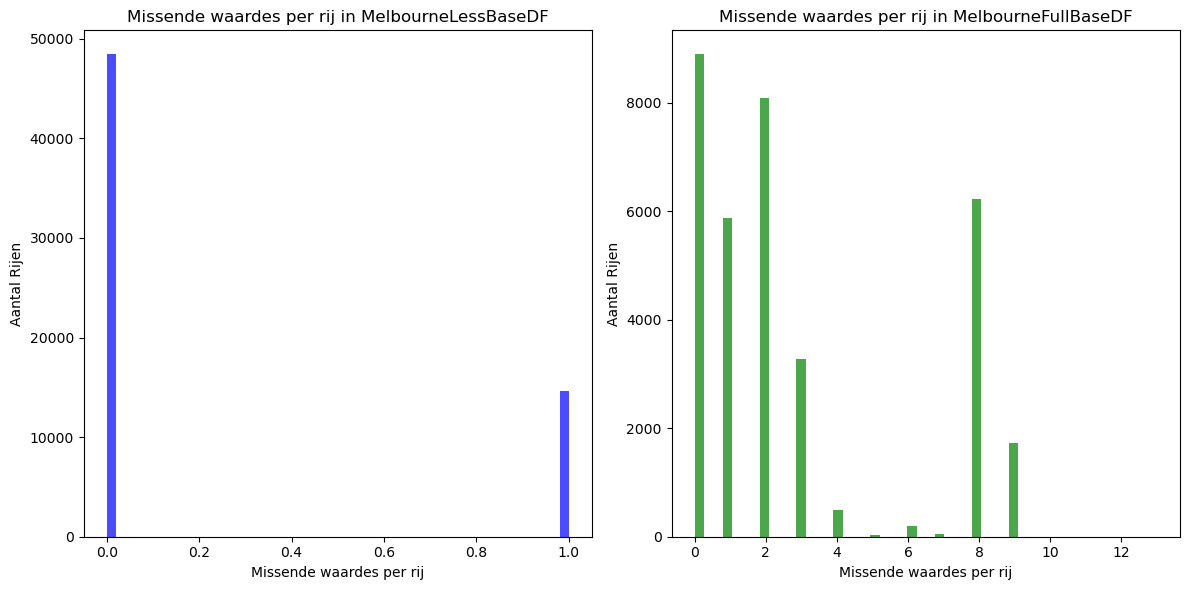

In [15]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(missing_per_row_less, bins=50, color='blue', alpha=0.7)
plt.title('Missende waardes per rij in MelbourneLessBaseDF')
plt.xlabel('Missende waardes per rij')
plt.ylabel('Aantal Rijen')

plt.subplot(1, 2, 2)
plt.hist(missing_per_row_full, bins=50, color='green', alpha=0.7)
plt.title('Missende waardes per rij in MelbourneFullBaseDF')
plt.xlabel('Missende waardes per rij')
plt.ylabel('Aantal Rijen')

plt.tight_layout()
plt.show()

De figuren laten duidelijk zien hoe de verdeling van missende waardes er uit ziet per dataset.

In het "Snapshot" bevat het merendeel totaal geen missende waardes, en is er nooit meer dan één missende waarde aanwezig binnenin de rijen die wel iets missen.

In de "Complete" dataset is er een veel grotere verspreiding waar te nemen, deze zal verder worden uitgelicht in de volgende tabel:

In [17]:
missing_per_row_full = MelbourneFullBaseDF.isnull().sum(axis=1)

missing_value_counts = missing_per_row_full.value_counts().sort_index()

missing_percentage = (missing_value_counts / total_rows_full) * 100

missing_table = pd.DataFrame({
    'Missende Waardes': missing_value_counts.index,
    'Aantal': missing_value_counts.values,
    'Percentage': missing_percentage.values
})

missing_table['Percentage'] = missing_table['Percentage'].apply(lambda x: f"{x:.2f}%")

missing_table = missing_table[missing_table['Missende Waardes'] <= 12]

display(missing_table)

,Missende Waardes,Aantal,Percentage
0,0,8887,25.50%
1,1,5867,16.83%
2,2,8083,23.19%
3,3,3280,9.41%
4,4,496,1.42%
5,5,32,0.09%
6,6,205,0.59%
7,7,57,0.16%
8,8,6229,17.87%
9,9,1718,4.93%


Deze verdeling versterkt de eerdere waarneming dat een redelijk groot aantal van de rijen minder dan drie missende waardes bevatten.

Het probleem is echter dat er opeens een grote piek ontstaat bij de waarneming van 8 missende waardes, dit nummer is belangrijk omdat we eerder hebben geconstateerd dat de "complete" dataset 8 kolommen bevat die niet voorkomen in het "snapshot".

De volgende handeling zal eerst het aantal rijen met precies 8 missende waardes filteren, waarna er wordt weergegeven bij welke kolommen dit voorkomt.
Indien het resultaat meer dan acht kolomnamen weergeeft, kan er verder onderzoek worden gedaan naar de percentuele verdeling van deze kolommen, maar als het acht specifieke namen zijn dan kunnen er meer conclusies worden getrokken over de rollen van de datasets.

In [19]:
rows_with_8_missing = MelbourneFullBaseDF[missing_per_row_full == 8]

columns_with_missing_values = rows_with_8_missing.columns[rows_with_8_missing.isnull().any()]

sorted_columns_with_missing_values = sorted(columns_with_missing_values)

missing_columns_df = pd.DataFrame(sorted_columns_with_missing_values, columns=['Kolommen met missende waardes'])

missing_columns_df.reset_index(drop=True, inplace=True)

display(missing_columns_df)

,Kolommen met missende waardes
0,Bathroom
1,Bedroom2
2,BuildingArea
3,Car
4,Landsize
5,Lattitude
6,Longtitude
7,YearBuilt


Het weergegeven resultaat bestaat uit precies acht kolommen, deze zouden meer inzicht kunnen geven wanneer er geconstateerd wordt of deze kolommen alleen toebehoren tot de "complete" dataset.

Om hier achter te komen worden de kolomnamen van beiden datasets met elkaar vergeleken, waarna er een lijst wordt uitgedraaid waarin de namen van de acht kolommen staan die niet in het "snapshot" staan.

In [21]:
columns_less = set(MelbourneLessBaseDF.columns)
columns_full = set(MelbourneFullBaseDF.columns)

only_in_full = sorted(list(columns_full - columns_less))

columns_comparison = pd.DataFrame({
    'Alleen in de Complete Dataset': only_in_full
})

columns_comparison.reset_index(drop=True, inplace=True)

display(columns_comparison)

,Alleen in de Complete Dataset
0,Bathroom
1,Bedroom2
2,BuildingArea
3,Car
4,Landsize
5,Lattitude
6,Longtitude
7,YearBuilt


De lijst met kolomnamen die voorkomen in rijen met precies 8 missende waardes komt geheel overeen met de lijst van kolommen die alleen in de "complete" dataset staan.

Dit suggereert dat deze kolommen mogelijk veel uit missende waardes bevatten, waardoor de verschillende rijen dus ook al sneller een missende waarde bevatten.

Om dit te testen zijn de acht kolommen samengevoegd als een entiteit "Groep 1", en is hetzelfde gedaan met de overige 15 kolommen in de vorm van "Groep 2". Hierna is er naar elke rij gekeken die een specifiek aantal missende waardes heeft, waarna er is gekeken hoeveel van die missende waardes onder welke groep vallen, en hoe deze dan in verhouding met elkaar staan.

In [23]:
group_1_columns = ['Bathroom', 'Bedroom2', 'BuildingArea', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'YearBuilt']
group_2_columns = [col for col in MelbourneFullBaseDF.columns if col not in group_1_columns]

df = MelbourneFullBaseDF.copy()

missing_in_group_1 = df[group_1_columns].isnull()
missing_in_group_2 = df[group_2_columns].isnull()

df['MissingCount'] = missing_in_group_1.sum(axis=1) + missing_in_group_2.sum(axis=1)

missing_proportions = pd.DataFrame(columns=['Groep 1', 'Groep 2'], index=range(1, 12))

for missing_count in range(1, 12):
    rows_with_missing = df[df['MissingCount'] == missing_count]
    
    group_1_missing = missing_in_group_1.loc[rows_with_missing.index].sum(axis=1).sum()
    group_2_missing = missing_in_group_2.loc[rows_with_missing.index].sum(axis=1).sum()
    
    total_missing = group_1_missing + group_2_missing
    if total_missing > 0:
        group_1_percentage = (group_1_missing / total_missing) * 100
        group_2_percentage = (group_2_missing / total_missing) * 100
    else:
        group_1_percentage = group_2_percentage = 0
        
    missing_proportions.loc[missing_count, 'Groep 1'] = f"{group_1_percentage:.2f}%"
    missing_proportions.loc[missing_count, 'Groep 2'] = f"{group_2_percentage:.2f}%"

display(missing_proportions)

,Groep 1,Groep 2
1,55.17%,44.83%
2,94.73%,5.27%
3,80.59%,19.41%
4,78.98%,21.02%
5,85.00%,15.00%
6,99.84%,0.16%
7,85.71%,14.29%
8,100.00%,0.00%
9,88.89%,11.11%
10,0.00%,0.00%


De bovenstaande weergave laat zien dat een heel groot aantal van missende waardes altijd bestaat uit een missende waarde binnenin 1 van de 8 kolommen binnnenin de "complete" dataset, wat dus inderdaad de indicatie geeft dat deze kolommen inderdaad de grootste reden zijn voor het aantal missende waardes binnenin de "complete" dataset.

Mogelijk is het "Snapshot" gebaseerd op de dataset zonder deze specifieke kolommen, en zijn er meer rijen gegenereerd gebaseerd op bestaande data.

Ondanks het feit dat het "Snapshot" een completere dataset is, past de "Complete" dataset meer bij het doel wat er voor ogen is, in dat meer kolommen meer mogelijkheden tot regressie aanbieden.

Om deze reden zal er in dit notebook verder worden gewerkt met de "Melbourne_housing_FULL" dataset, oftewel het "MelbourneFullBaseDF" Dataframe.

<h2><b>Melbourne Housing FULL</b></h2>

Er is al gekeken naar de vorm en omschrijving van deze dataset, maar het is ook belangrijk om in te zien hoe de specifieke kolommen er uit zien, en wat voor verschillende waardes er in elke kolom kunnen staan.

Op deze manier kan er in een oogopslag worden gezien of er mogelijk iets mis is met het datatype of de manier waarop een waarde is neergeschreven binnnenin een specifieke kolom:

In [26]:
MelbourneFullBaseDF.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

In [27]:
MelbourneFullBaseDF.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In een oogopslag lijkt alles acceptabel te zijn, al zijn er een aantal kleine opvallende waarnemingen die niet perse veel uitmaken voor de regressie, maar wel even worden gecorrigeerd voor gebruik in algoritmes:

- Numerieke kolommen zouden consistent moeten zijn: "Rooms", "Car", "Bedroom2", "Propertycount", en "Bathroom" zijn allemaal kolommen die een aantal zonder decimaal aangeven, wat betekend dat deze ook hetzelfde datatype zouden moeten hebben. Er kan namelijk geen anderhalve badkamer, of auto gedefinieerd worden, wat betekend dat deze allemaal integers zijn.
- Sommige numerieke kolommen bevatten geen nummers waarmee calculaties worden gedaan: "Postcode" en "YearBuilt" bestaan beiden uit nummers die eerder als een string moeten worden gezien.
- Datums zouden een Datetime formaat moeten hebben: Dit betekend dat "Date" geconverteerd zou moeten worden.
- Een foutieve naam voor "latitude" en "longitude" in dat er in beiden woorden een extra "-t" staat.

In [29]:
MelbourneFullBaseDF["Date"] = pd.to_datetime(MelbourneFullBaseDF["Date"],dayfirst=True)

In [30]:
print("Datatype van 'Date' kolom:", MelbourneFullBaseDF['Date'].dtype)

print(MelbourneFullBaseDF['Date'].head())

Datatype van 'Date' kolom: datetime64[ns]
0   2016-09-03
1   2016-12-03
2   2016-02-04
3   2016-02-04
4   2017-03-04
Name: Date, dtype: datetime64[ns]


Bovenstaande code heeft de originele datums omgezet naar een ISO 8601 formaat, waarna deze ook geprint zijn om te checken of de structuur nog correct is.

Eenzelfde methode zal nu gebruikt worden om de datatypes van de telbare numerieke kolommen om te zetten naar Integers. Ondanks het feit dat er al een aantal kolommen waren uitgelicht, zal er een code worden gebruikt om te bepalen welke kolommen een Float datatype moeten behouden, en welke gewoonweg een Integer kunnen zijn.

Hiervoor wordt er gekeken in elke kolom, en wordt er uitgelicht of er een decimaal (anders dan 0) aanwezig is, als dit het geval is, dan wordt deze kolom neergeschreven.

In [32]:
numeric_columns = MelbourneFullBaseDF.select_dtypes(include=["number"]).columns

for col in numeric_columns:
    decimal_rows = MelbourneFullBaseDF[pd.notna(MelbourneFullBaseDF[col]) & (MelbourneFullBaseDF[col] % 1 != 0)]
    
    if not decimal_rows.empty:
        print(f"Kolom '{col}' heeft decimale waardes")

Kolom 'Distance' heeft decimale waardes
Kolom 'BuildingArea' heeft decimale waardes
Kolom 'Lattitude' heeft decimale waardes
Kolom 'Longtitude' heeft decimale waardes


Dit betekend dat de volgende kolommen geconverteerd moeten worden naar een Integer:

- Price
- Bedroom2
- Bathroom
- Car
- Landsize
- Propertycount
- YearBuilt (Dit is een geheel jaartal, en maakt dus geen gebruik van het datetime formaat)

De overige numerieke kolom "Postcode" wordt ook geconverteerd naar een Integer om het decimaal weg te halen, daarna wordt deze verder geconverteerd naar een String.

In [34]:
columns_to_convert = ["Price", "Bedroom2", "Bathroom", "Car", "Landsize", "Propertycount", "YearBuilt", "Postcode"]

for col in columns_to_convert:
    if col in MelbourneFullBaseDF.columns:
        MelbourneFullBaseDF[col] = MelbourneFullBaseDF[col].astype("Int64")

print(MelbourneFullBaseDF[columns_to_convert].dtypes)

Price            Int64
Bedroom2         Int64
Bathroom         Int64
Car              Int64
Landsize         Int64
Propertycount    Int64
YearBuilt        Int64
Postcode         Int64
dtype: object


In [35]:
MelbourneFullBaseDF['Postcode'] = MelbourneFullBaseDF['Postcode'].astype(str)
print(MelbourneFullBaseDF['Postcode'])

0        3067
1        3067
2        3067
3        3067
4        3067
         ... 
34852    3013
34853    3013
34854    3013
34855    3013
34856    3013
Name: Postcode, Length: 34857, dtype: object


Tenslotte zullen "Lattitude" en "Longtitude" hernoemd worden naar "Latitude" en "Longitude", gewoonweg zodat deze spelfouten niet steeds terugkomen.

In [37]:
MelbourneFullBaseDF.rename(columns={'Lattitude': 'Latitude', 'Longtitude': 'Longitude'}, inplace=True)

In [38]:
MelbourneFullBaseDF.dtypes

Suburb                   object
Address                  object
Rooms                     int64
Type                     object
Price                     Int64
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                 object
Bedroom2                  Int64
Bathroom                  Int64
Car                       Int64
Landsize                  Int64
BuildingArea            float64
YearBuilt                 Int64
CouncilArea              object
Latitude                float64
Longitude               float64
Regionname               object
Propertycount             Int64
dtype: object

In [39]:
MelbourneFullBaseDF.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,<NA>,SS,Jellis,2016-09-03,2.5,3067,...,1,1,126,NaN,<NA>,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019
1,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,2016-12-03,2.5,3067,...,1,1,202,NaN,<NA>,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019
2,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2016-02-04,2.5,3067,...,1,0,156,79.0,1900,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019
3,Abbotsford,18/659 Victoria St,3,u,<NA>,VB,Rounds,2016-02-04,2.5,3067,...,2,1,0,NaN,<NA>,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019
4,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,2017-03-04,2.5,3067,...,2,0,134,150.0,1900,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019


De dataset bevat nu de correcte datatypes voor elke kolom, wat er voor zorgt dat elke waarde nu ook correct is neergeschreven.

Zoals eerder is aangegeven, bevat deze dataset een heel aantal missende waardes, vooral voortkomend uit de acht extra kolommen. Gezien deze kolommen belangrijk zijn voor de toepassing van regressie, is het belangrijk dat er gebruik wordt gemaakt van imputatie om deze waardes in te vullen.

Allereerst zullen alle kolommen nogmaals worden weergegeven, waarna er wordt gekeken welke kolommen imputatie nodig hebben, en op welke manier dat wordt gedaan.

In [41]:
missing_info = MelbourneFullBaseDF.isnull().sum().to_frame(name="Missing Values")
missing_info["Total Rows"] = len(MelbourneFullBaseDF)
missing_info["Percentage"] = (missing_info["Missing Values"] / missing_info["Total Rows"]) * 100

missing_info["Percentage"] = missing_info["Percentage"].map(lambda x: f"{x:.2f}%")
missing_info = missing_info.sort_values(by="Missing Values", ascending=False)

print(missing_info)

               Missing Values  Total Rows Percentage
BuildingArea            21115       34857     60.58%
YearBuilt               19306       34857     55.39%
Landsize                11810       34857     33.88%
Car                      8728       34857     25.04%
Bathroom                 8226       34857     23.60%
Bedroom2                 8217       34857     23.57%
Longitude                7976       34857     22.88%
Latitude                 7976       34857     22.88%
Price                    7610       34857     21.83%
Regionname                  3       34857      0.01%
CouncilArea                 3       34857      0.01%
Propertycount               3       34857      0.01%
Distance                    1       34857      0.00%
Address                     0       34857      0.00%
Postcode                    0       34857      0.00%
Date                        0       34857      0.00%
SellerG                     0       34857      0.00%
Method                      0       34857     

Op basis van bovenstaande informatie zijn de volgende handelingen beredeneerd:

- Kolommen met 0.01% missende waardes zullen worden ingevuld met een simpele imputatie in de vorm van "gemiddelde" of "meest voorkomend".
- Kolommen met tussen de 20% - 50% missende waardes zullen worden ingevuld met imputatiemethodes zoals "gemiddelde" en "regressie", of worden gebaseerd op de waardes binnenin andere kolommen.
- Kolommen die meer dan 50% missende waardes bevatten zullen beter worden bekeken om te besluiten wat daarmee gedaan gaat worden, hierbij wordt vooral gekeken of deze genoeg bij gaan dragen aan de latere regressie machine learning.

<h2><b><1% Missende Waardes</b></h2>

Deze kolommen bevatten maar een ontzettend klein aantal missende waardes, die vrijwel geen verschil gaan maken in de functie van de regressie machine learning. Om deze reden kan hier een simpele imputatie functie voor worden gebruikt, waarbij de categorische kolommen de meest voorkomende waarde krijgen, terwijl de numerieke kolommen de gemiddelde waarde krijgen.

Tenslotte wordt na deze imputatie gecheckt of er nog missende waardes voorkomen in deze kolommen.

In [43]:
categorical_columns = ['Regionname', 'CouncilArea']
numerical_columns = ['Propertycount', 'Distance']

categorical_imputer = SimpleImputer(strategy='most_frequent')

numerical_imputer = SimpleImputer(strategy='mean')

MelbourneFullBaseDF[categorical_columns] = categorical_imputer.fit_transform(MelbourneFullBaseDF[categorical_columns])

MelbourneFullBaseDF[numerical_columns] = numerical_imputer.fit_transform(MelbourneFullBaseDF[numerical_columns])

print(MelbourneFullBaseDF[categorical_columns + numerical_columns].isnull().sum())

Regionname       0
CouncilArea      0
Propertycount    0
Distance         0
dtype: int64


<h2><b>20% - 50% Missende Waardes</b></h2>

Dit zijn de telbare kolommen in de vorm van "Car", "Bathroom", en "Bedroom2", locatie-gerelateerde data in de vorm van breedte- en lengtegraad, oppervlakte-gerelateerde kolommen in de vorm van Landsize, en het uiteindelijke doel voor de regressie in de vorm van de woonprijs.

De telbare kolommen zijn heel belangrijk in het vaststellen van regressie, omdat het logisch is dat het bevatten van meer ruimtes en voorzieningen betekend dat de prijs van een huis omhoog kan gaan.

De prijs gaat niet geïmputeerd worden, hierop wordt namelijk de Machine-Learning toegepast. Omdat er maar 20% mist, zal dit weinig problemen geven.

<b>Car</b>

De enige telbare kolom die echter geen tot weinig waarde voor de regressie lijkt te hebben is "Car", de waardes in deze kolom zijn meestal 1 of 2, en zijn onduidelijk in wat deze waarde nu uiteindelijk betekend. Om deze redenen zal een simpele imputatie methode worden gebruikt in de vorm van een willekeurige invulling gebaseerd op de bestaande waardes in de dataset.

Hiervoor zullen eerst alle waardes in de "Car" kolom die niet missen worden geëvalueerd, waarna de missende waardes willekeurig worden ingevuld gebaseerd op deze waardes.

In [45]:
existing_values = MelbourneFullBaseDF['Car'].dropna().values

MelbourneFullBaseDF.loc[MelbourneFullBaseDF['Car'].isna(), 'Car'] = np.random.choice(existing_values, 
                                                                                              size=MelbourneFullBaseDF['Car'].isna().sum(), 
                                                                                              replace=True).astype(float)

De volgende stap in het imputatieproces voor deze sectie is gebaseerd op hoe veel bewerkingen moeten worden gedaan, momenteel zijn de breedte- en lengtegraad te baseren op de CouncilArea en Suburb, beiden missen geen waardes en zouden dus makkelijk de mogelijkheid kunnen aanbieden om een preciese imputatie te implementeren.

<b>Latitude & Longitude</b>

De breedte- en lengtegraad kolommen kunnen mogelijk makkelijk in worden gevuld indien alle waardes hetzelfde zijn voor bepaalde voorsteden en de bijbehorende disctrictsraad, dit zal dan ook eerst onderzocht worden voordat er een imputatie methode wordt toegepast.

Hiervoor zal eerst worden bekeken hoeveel unieke voorsteden aanwezig zijn, en daarna hoeveel unieke coördinaten aanwezig zijn. Als deze overeenkomen kunnen de missende waardes, na een controle, gewoonweg in worden gevuld gebaseerd op locatie.

In [47]:
unique_suburbs = MelbourneFullBaseDF['Suburb'].nunique()

unique_coordinates = MelbourneFullBaseDF[['Longitude', 'Latitude']].dropna().nunique()

print(f"Aantal unieke suburbs: {unique_suburbs}")
print(f"Aantal unieke coördinaatcombinaties: {unique_coordinates}")

Aantal unieke suburbs: 351
Aantal unieke coördinaatcombinaties: Longitude    14524
Latitude     13402
dtype: int64


Deze bevinding geeft aan dat er niet alleen dezelfde combinatie van coördinaten passen bij elke unieke voorstad.

De volgende stap is om te bekijken hoe de coördinaten passen bij de verschillende regio's. indien er te zien is dat elke regio een bepaald bereik aan coördinaten heeft, dan is het makkelijker om hiermee een specifiekere imputatie toe te passen.

Hiervoor zal dus eerst in kaart worden gebracht hoe de verspreiding van coördinaten er uit ziet per regio.

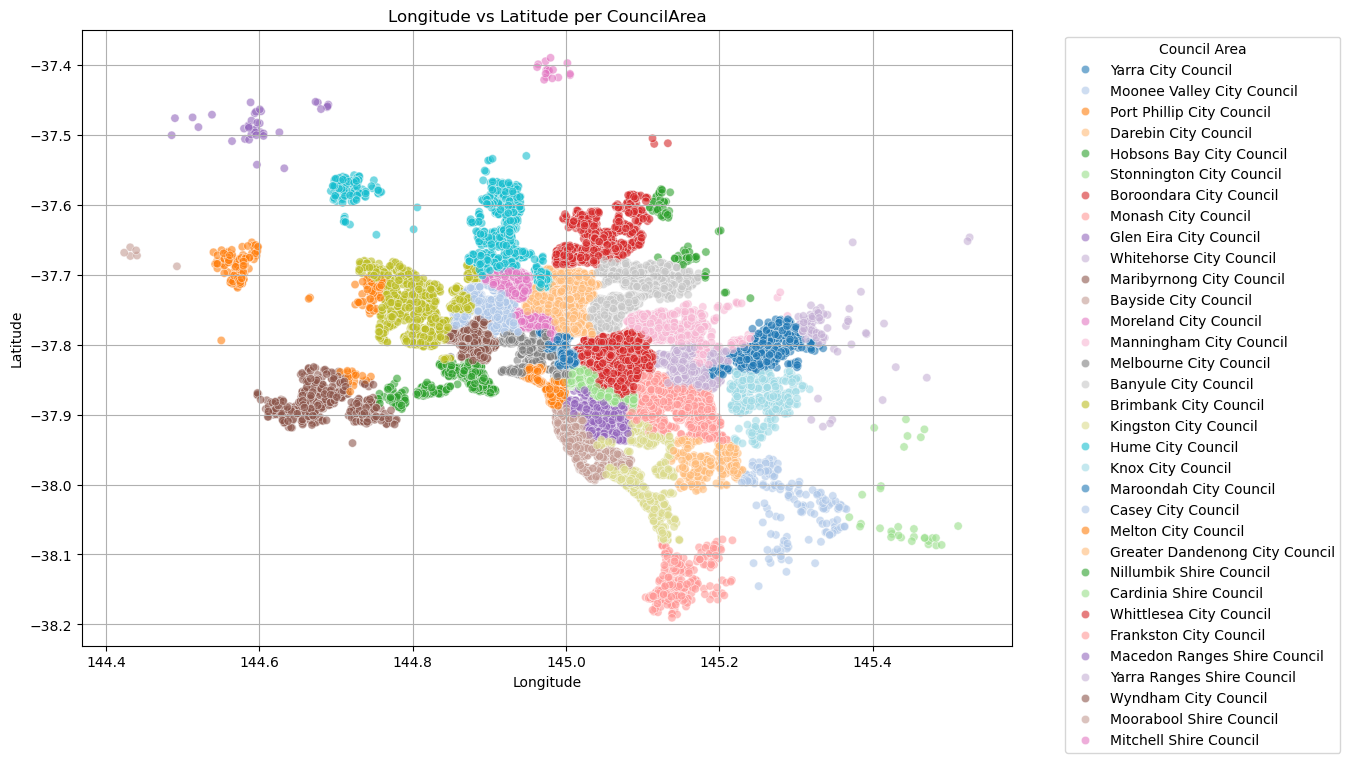

In [49]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=MelbourneFullBaseDF,
    x="Longitude",
    y="Latitude",
    hue="CouncilArea",
    palette="tab20",
    alpha=0.6
)

plt.title("Longitude vs Latitude per CouncilArea")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Council Area", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

In een oogopslag lijken de waardes niet te overlappen, al is het beter om dit na te gaan met een code die aangeeft of er ergens een overlap is.

Voor deze code worden de coördinaten per regio gegroepeerd, waarna coördinaten combinaties die maar 1 keer voorkomen niet worden overwogen.
Als er coördinaten over blijven, worden deze geprint samen met de voorsteden en regio's waarin deze voorkomen, zo niet dan zijn er geen duplicaten.

In [51]:
overlap_df = MelbourneFullBaseDF.groupby(['Longitude', 'Latitude'])['CouncilArea'].nunique().reset_index(name='CouncilAreaCount')

overlap_df = overlap_df[overlap_df['CouncilAreaCount'] > 1]

if not overlap_df.empty:
    example_overlap = overlap_df.iloc[0]
    longitude = example_overlap['Longitude']
    latitude = example_overlap['Latitude']
    
    overlapping_rows = MelbourneFullBaseDF[(MelbourneFullBaseDF['Longitude'] == longitude) & 
                                           (MelbourneFullBaseDF['Latitude'] == latitude)]
    
    print(f"Overlapping Coordinates: Longitude = {longitude}, Latitude = {latitude}")
    print("Unieke Council Areas met overlappende coördinaten:")
    print(overlapping_rows[['Suburb', 'CouncilArea']].drop_duplicates())
else:
    print("Geen overlappende coördinaten gevonden binnenin unieke council areas.")

Geen overlappende coördinaten gevonden binnenin unieke council areas.


Omdat bovenstaande code aangeeft dat er geen overlap in unieke coördinaten plaatsvind in de unieke regio's, loont het om nogmaals de verschillende voorsteden per regio te bekijken, om te achterhalen of deze ook unieke coördinaten bevat. Wanneer hier namelijk uitkomt of dit wel of niet het geval is, wordt het makkelijker om een imputatiemethode toe te passen.

De volgende code zal eerst aangeven of een voorstad aanwezig is in meerdere regio's, waarna een specifieke regio als voorbeeld wordt gebruikt om de verdeling van coördinaten binnenin de bijbehorende voorsteden weer te geven. 

In [53]:
suburb_council_areas = MelbourneFullBaseDF.groupby('Suburb')['CouncilArea'].unique()

suburbs_multiple_areas = suburb_council_areas[suburb_council_areas.apply(lambda x: len(x) > 1)]

print("Voorsteden die binnen meerdere regio's vallen:")
for suburb, council_areas in suburbs_multiple_areas.items():
    print(f"{suburb}: {', '.join(council_areas)}")

Voorsteden die binnen meerdere regio's vallen:
Footscray: Maribyrnong City Council, Boroondara City Council


Omdat er maar een voorstad is die onder meerdere regio's valt, en omdat deze dataset is gebaseerd op de werkelijkheid, is het heel makkelijk om gewoonweg te achterhalen in welke regio deze voorstad daadwerkelijk valt, zodat het eerdere plan kan worden uitgevoerd.

Online is al heel snel te vinden dat Footscray deel uitmaakt van Maribyrnong, wat betekend dat deze eerst moet worden aangepast in de data voordat het plan wordt voortgezet.

In [55]:
rows_to_change = MelbourneFullBaseDF[(MelbourneFullBaseDF['Suburb'] == 'Footscray') & 
                                     (MelbourneFullBaseDF['CouncilArea'] == 'Boroondara City Council')]

MelbourneFullBaseDF.loc[(MelbourneFullBaseDF['Suburb'] == 'Footscray') & 
                        (MelbourneFullBaseDF['CouncilArea'] == 'Boroondara City Council'), 'CouncilArea'] = 'Maribyrnong City Council'

print(f"Aantal veranderde rijen: {len(rows_to_change)}")

Aantal veranderde rijen: 1


Uit deze code is bevonden dat er een foutieve waarde in deze dataset stond gebaseerd op voorstad locatie, wat tegelijkertijd ook bevestigd dat de voorsteden dus ook daadwerkelijk correct zijn ingevuld bij de relevante regio.

Deze bevinding insinueerd dat de volgende stap, het koppelen van voorsteden aan een bereik van coördinaten, ook zal gaan werken.
Deze bewerking zal er voor zorgen dat al deze missende waardes voor breedte- en lengtegraad op een correcte manier worden geïmputeerd.

De volgende code geeft vier willekeurige scatterplot weer van 1 gemeente met de bijbehorende voorsteden, om te checken hoe deze gegenereerd worden.

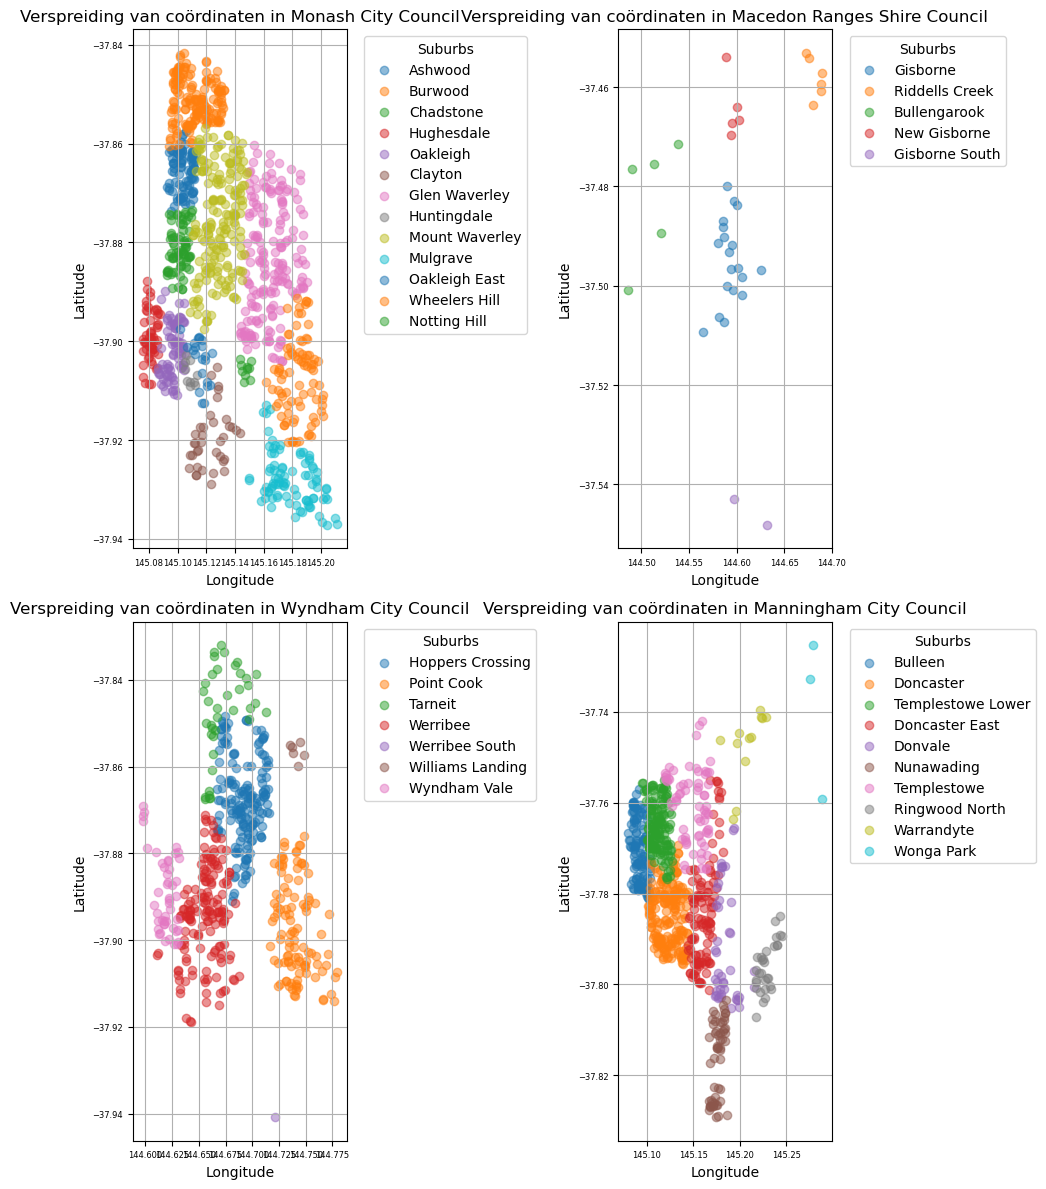

In [57]:
unique_councilareas = MelbourneFullBaseDF['CouncilArea'].unique()

random_councilareas = random.sample(list(unique_councilareas), 4)

plt.figure(figsize=(10, 12))

for i, council_area in enumerate(random_councilareas, 1):
    plt.subplot(2, 2, i)
    
    council_df = MelbourneFullBaseDF[MelbourneFullBaseDF['CouncilArea'] == council_area]
    
    for suburb in council_df['Suburb'].unique():
        suburb_data = council_df[council_df['Suburb'] == suburb]
        plt.scatter(suburb_data['Longitude'], suburb_data['Latitude'], label=suburb, alpha=0.5)
    
    plt.title(f'Verspreiding van coördinaten in {council_area}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(title='Suburbs', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tick_params(axis='both', labelsize=6)

plt.tight_layout()
plt.show()

Net zoals voor de regio's is er niet met zekerheid te zeggen of er overlappende waardes zijn, waardoor er weer een code moet worden geschreven om dit te checken.

Indien er geen overlap is, zal het volgende gedeelte over de imputatie van missende waardes gaan.

In [59]:
overlap_df = MelbourneFullBaseDF.groupby(['Longitude', 'Latitude', 'Suburb'])['CouncilArea'].nunique().reset_index(name='CouncilAreaCount')

overlap_df = overlap_df[overlap_df['CouncilAreaCount'] > 1]

if not overlap_df.empty:
    example_overlap = overlap_df.iloc[0]
    longitude = example_overlap['Longitude']
    latitude = example_overlap['Latitude']
    overlapping_rows = MelbourneFullBaseDF[(MelbourneFullBaseDF['Longitude'] == longitude) & 
                                           (MelbourneFullBaseDF['Latitude'] == latitude) & 
                                           (MelbourneFullBaseDF['Suburb'] == example_overlap['Suburb'])]
    
    print(f"Overlapping Coordinates: Longitude = {longitude}, Latitude = {latitude}")
    print("Overlappende Voorsteden met coördinaten:")
    print(overlapping_rows[['Suburb', 'CouncilArea']].drop_duplicates())
else:
    print("Geen overlappende coördinaten gevonden binnenin unieke voorsteden.")

Geen overlappende coördinaten gevonden binnenin unieke voorsteden.


Omdat ook deze code aangeeft dat er geen overlappende waardes aanwezig zijn, is het mogelijk om de missende coördinaten te imputeren.

Om deze imputatie te realiseren worden de missende waardes uitgelicht, waarna deze worden ingevuld op basis van de gemiddelde waarde van de coördinaten gebaseerd op de respectieve voorstad.

Deze veranderingen worden toegepast op het huidige dataframe, waarna er wordt gecontroleerd of deze veranderingen ook succesvol zijn uitgevoerd doormiddel van het opnieuw printen van missende waardes binnenin de "Longitude" en "Latitude" kolommen.

In [61]:
mean_coordinates = MelbourneFullBaseDF.groupby('Suburb')[['Longitude', 'Latitude']].mean()

def impute_coordinates(row):
    if pd.isnull(row['Longitude']):
        row['Longitude'] = mean_coordinates.loc[row['Suburb'], 'Longitude']
    if pd.isnull(row['Latitude']):
        row['Latitude'] = mean_coordinates.loc[row['Suburb'], 'Latitude']
    return row

MelbourneFullBaseDF = MelbourneFullBaseDF.apply(impute_coordinates, axis=1)

print(MelbourneFullBaseDF[['Suburb', 'Longitude', 'Latitude']].isnull().sum())

Suburb        0
Longitude    88
Latitude     88
dtype: int64


Ondanks het feit dat de "Suburb" kolom totaal geen missende waardes bevat, is de imputatie niet volledig succesvol om een of andere reden.

Om na te gaan wat het probleem is, zullen er meerdere onderzoekende methodes gebruikt worden of dit te achterhalen.
Ten eerste zal er worden gecheckt of deze waardes te maken hebben met een specifieke voorstad.

In [63]:
missing_data_by_suburb = MelbourneFullBaseDF[MelbourneFullBaseDF[['Longitude', 'Latitude']].isna().any(axis=1)].groupby('Suburb').size()
print(missing_data_by_suburb)

Suburb
Cranbourne East     1
Fawkner Lot         1
MacLeod            83
Olinda              1
croydon             1
viewbank            1
dtype: int64


Uit deze resultaten valt af te lezen dat vijf van de zes benoemde voorsteden allemaal maar 1 keer voorkomen, mogelijk zijn dit dus voorsteden die maar een keer vookomen in de gehele dataset, en daardoor geen andere rijen als referentie hadden om de waardes in te vullen op basis van de imputatie.

Om dit te checken zal er voor deze voorsteden worden gekeken hoe vaak deze voorkomen in de dataset.

In [65]:
suburb_counts = MelbourneFullBaseDF['Suburb'].value_counts()

specific_suburbs = ['Cranbourne East', 'Fawkner Lot', 'MacLeod', 'Olinda', 'croydon', 'viewbank']
print(suburb_counts[specific_suburbs])

Suburb
Cranbourne East     1
Fawkner Lot         1
MacLeod            83
Olinda              1
croydon             1
viewbank            1
Name: count, dtype: int64


Deze waarneming laat inderdaad zien dat deze voorsteden maar een aantal keer voorkomen, waardoor er geen andere referentie is voor de imputatie.

Alleen MacLeod heeft een groter aantal missende waardes en voorkomingen, maar in het grote geheel is dit ook maar ~0.24% van alle data.

Omdat deze data niet veel invloed gaan hebben op toekomstige berekeningen, is het plan nu om de imputatie niet te baseren op de gemiddelde waarde van de desbetreffende voorstad, maar een stapje omlaag te gaan en het te laten baseren op de desbetreffende regio.

Deze handeling zal niet voor enige problemen zorgen omdat het niet veel data betreft en nog steeds redelijk nauwkeurige data imputeert die overeenkomt met de regio.

In [67]:
council_area_avg = MelbourneFullBaseDF.groupby('CouncilArea')[['Longitude', 'Latitude']].mean()
MelbourneFullBaseDF['Longitude'] = MelbourneFullBaseDF['Longitude'].fillna(MelbourneFullBaseDF['CouncilArea'].map(council_area_avg['Longitude']))
MelbourneFullBaseDF['Latitude'] = MelbourneFullBaseDF['Latitude'].fillna(MelbourneFullBaseDF['CouncilArea'].map(council_area_avg['Latitude']))

print(MelbourneFullBaseDF[['Longitude', 'Latitude']].isnull().sum())

Longitude    0
Latitude     0
dtype: int64


Al deze uitvoeringen hebben ervoor gezorgd dat de missende waardes binnenin de "longitude" en "latitude" kolommen allemaal zijn ingevuld gebaseerd op de gemiddelde waarde van de desbetreffende voorstad, en voor de unieke gevallen, de gemiddelde waarde van de desbetreffende regio.

Deze handelingen zorgen ervoor dat er een nauwkeurige machine learning kan worden toegepast om zo een relatie te ontdekken tussen de prijs van huizen en de locatie van deze huizen.

<b>Rooms</b>

In [70]:
MelbourneFullBaseDF['Bedrooms per room'] = MelbourneFullBaseDF['Bedroom2'] / MelbourneFullBaseDF['Rooms']
 
mean_bedrooms_per_sqm = MelbourneFullBaseDF['Bedrooms per room'].mean()

MelbourneFullBaseDF['Bedroom2'].fillna(MelbourneFullBaseDF['Rooms'] * mean_bedrooms_per_sqm, inplace=True)

MelbourneFullBaseDF['Bedroom2'] = MelbourneFullBaseDF['Bedroom2'].round()

MelbourneFullBaseDF.drop(columns=['Bedrooms per room'], inplace=True)

display(MelbourneFullBaseDF[['Bedroom2', 'Rooms']].head(10))

C:\Users\luukk\AppData\Local\Temp\ipykernel_23232\2868467641.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  MelbourneFullBaseDF['Bedroom2'].fillna(MelbourneFullBaseDF['Rooms'] * mean_bedrooms_per_sqm, inplace=True)
C:\Users\luukk\AppData\Local\Temp\ipykernel_23232\2868467641.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_do

,Bedroom2,Rooms
0,2.0,2
1,2.0,2
2,2.0,2
3,3.0,3
4,3.0,3
5,3.0,3
6,3.0,4
7,3.0,4
8,4.0,2
9,3.0,2


<b>Bathroom</b>

In [72]:
MelbourneFullBaseDF['Bathrooms per room'] = MelbourneFullBaseDF['Bathroom'] / MelbourneFullBaseDF['Rooms']
 
mean_bedrooms_per_sqm = MelbourneFullBaseDF['Bathrooms per room'].mean()

MelbourneFullBaseDF['Bathroom'].fillna(MelbourneFullBaseDF['Rooms'] * mean_bedrooms_per_sqm, inplace=True)

MelbourneFullBaseDF['Bathroom'] = MelbourneFullBaseDF['Bathroom'].round()

MelbourneFullBaseDF.drop(columns=['Bathrooms per room'], inplace=True)

display(MelbourneFullBaseDF[['Bathroom', 'Rooms']].head(10))

C:\Users\luukk\AppData\Local\Temp\ipykernel_23232\3860378351.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  MelbourneFullBaseDF['Bathroom'].fillna(MelbourneFullBaseDF['Rooms'] * mean_bedrooms_per_sqm, inplace=True)
C:\Users\luukk\AppData\Local\Temp\ipykernel_23232\3860378351.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_do

,Bathroom,Rooms
0,1.0,2
1,1.0,2
2,1.0,2
3,2.0,3
4,2.0,3
5,2.0,3
6,1.0,4
7,2.0,4
8,1.0,2
9,2.0,2


bevindingen.

<b>Landsize en BuildingArea</b>

De Landsize kolom bevat data waarin het aantal vierkante meters is neergeschreven voor het gehele gebied van de woning.

Op het moment is de beredenering dat de BuildingArea het oppervlakte van het huis zelf is, omdat deze vrijwel altijd wat kleiner is dan de Landsize kolom. Om dit zeker te weten zal dit inzicht eerst onderzocht worden door de hoeveelheid rijen uit te lichten die een grotere BuildingArea hebben dan Landsize.

In [74]:
filtered_df = MelbourneFullBaseDF.dropna(subset=['BuildingArea', 'Landsize'])
count_building_area_larger_than_landsize = filtered_df[filtered_df['BuildingArea'] > filtered_df['Landsize']].shape[0]
total_rows = MelbourneFullBaseDF.shape[0]
percentage = (count_building_area_larger_than_landsize / total_rows) * 100

print(f"Number of rows where BuildingArea is larger than Landsize: {count_building_area_larger_than_landsize}")
print(f"Percentage: {percentage:.2f}%")

Number of rows where BuildingArea is larger than Landsize: 1751
Percentage: 5.02%


Er is te zien dat maar een klein deel van de rijen data bevat waarin de BuildingArea groter is dan de Landsize, wat genoeg reden geeft om te bedenken dat dit maar heel weinig voorkomt, en dat de norm is dat de Landgrootte altijd groter is dan het bouwgebied.

Dit is een waardevolle observatie voor de imputatie, in dat het een regel toevoegd om missende waardes te bepalen.
Omdat er duidelijk een relatie bestaat tussen BuildingArea en Landsize, is het interessant om deze te ontdekken om een mogelijke regressie imputatie toe te passen om de waardes in te vullen.

Er zijn natuurlijk altijd uitzonderingen in dat er huizen zijn met veel meer land, maar deze zullen zo veel mogelijk worden gecorrigeerd doormiddel van de regressie gebaseerd op de respectieve wijken.

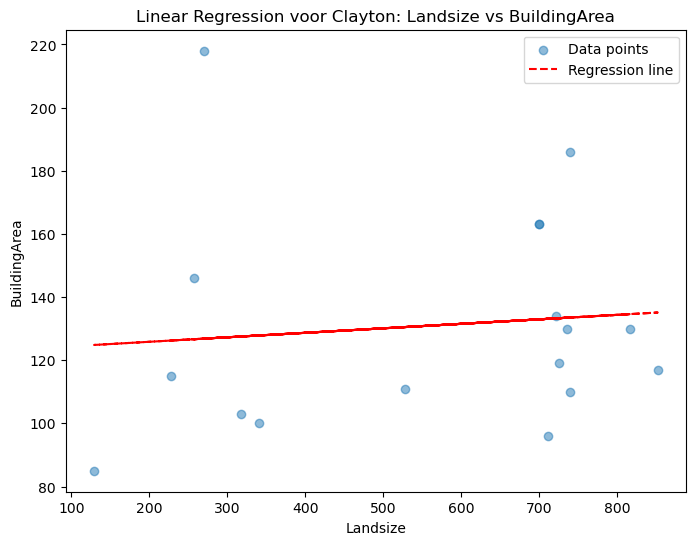

Linear Regression Model voor Clayton:
Slope: 0.01
Intercept: 122.99
Pearson Correlation: 0.10


In [76]:
filtered_df = MelbourneFullBaseDF.dropna(subset=['Landsize', 'BuildingArea'])
clayton_df = filtered_df[filtered_df['Suburb'] == 'Clayton']

if len(clayton_df) > 0:
    X = clayton_df['Landsize'].values.reshape(-1, 1)
    y = clayton_df['BuildingArea'].values
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(clayton_df['Landsize'], clayton_df['BuildingArea'], label='Data points', alpha=0.5)
    plt.plot(clayton_df['Landsize'], y_pred, color='red', label='Regression line', linestyle='--')
    plt.xlabel('Landsize')
    plt.ylabel('BuildingArea')
    plt.title('Linear Regression voor Clayton: Landsize vs BuildingArea')
    plt.legend()
    plt.show()

    print(f"Linear Regression Model voor Clayton:")
    print(f"Slope: {model.coef_[0]:.2f}")
    print(f"Intercept: {model.intercept_:.2f}")
    print(f"Pearson Correlation: {clayton_df['Landsize'].corr(clayton_df['BuildingArea']):.2f}")
else:
    print("No data available for 'Clayton'.")

Bovenstaande weergave en bijbehorende informatie laat zien dat de relatie ontzettend zwak is, wat betekend dat deze imputatie methode niet geschikt is om deze missende waardes te bepalen.

Een mogelijke oplossing is om in te zien wat de numerieke verschillen tussen de twee waardes in dezelfde rij zijn, zodat er mogelijk daar een relatie kan worden g

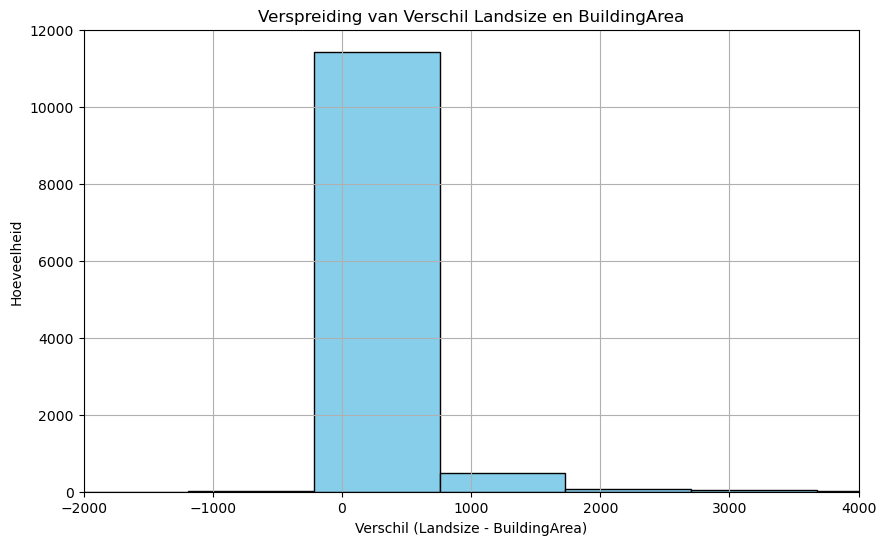

In [78]:
filtered_df = MelbourneFullBaseDF.dropna(subset=['Landsize', 'BuildingArea']).copy()

filtered_df['Difference'] = filtered_df['Landsize'] - filtered_df['BuildingArea']

plt.figure(figsize=(10, 6))
plt.hist(filtered_df['Difference'], bins=50, color='skyblue', edgecolor='black')
plt.xlim(-2000, 4000)
plt.xlabel('Verschil (Landsize - BuildingArea)')
plt.ylabel('Hoeveelheid')
plt.title('Verspreiding van Verschil Landsize en BuildingArea')
plt.grid(True)
plt.show()

Bovenstaande visualisatie geeft de verspreiding van de verschillen weer, waarbij het duidelijk is dat er een redelijk normale verspreiding van waardes aanwezig is. Echter zijn er ook een aantal waardes die vreemd zijn, die eigenlijk niet zouden moeten kloppen. Het is belangrijk om in kaart te brengen hoeveel van deze waardes aanwezig zijn, en of deze mogelijk kunnen zorgen voor verstoringen in het imputatie proces.

In het histogram is af te lezen dat de weinig aantallen gebeuren rondom 1800. Deze hoeveelheden zullen in een ander histogram worden weergegeven:

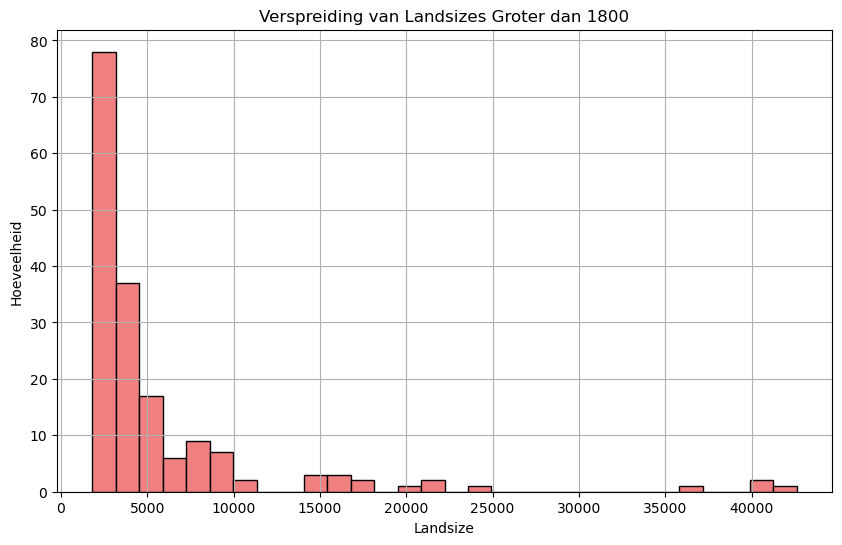

Total properties with Landsize > 1800: 172 (1.42%) out of 12140


In [80]:
large_difference_df = filtered_df[filtered_df['Difference'] > 1800]

plt.figure(figsize=(10, 6))
plt.hist(large_difference_df['Difference'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Landsize')
plt.ylabel('Hoeveelheid')
plt.title('Verspreiding van Landsizes Groter dan 1800')
plt.grid(True)
plt.show()

num_large_properties = large_difference_df.shape[0]
total_properties = filtered_df.shape[0]
percentage = (num_large_properties / total_properties) * 100

print(f'Total properties with Landsize > 1800: {num_large_properties} ({percentage:.2f}%) out of {total_properties}')

Uit dit histogram is af te lezen dat er een maar een klein aantal waardes (1.42%) bestaat uit uitschieters, wat betekend dat deze verwaarloosd kunnen worden in de overweging binnenin de imputatie.

Nu dat alle waardes voor de verschillende wijken geverifieerd is, kan deze worden toegepast op de missende waardes.
Als het ware kunnen de waardes geïmputeerd worden door de formules om te draaien:

De originele formule is <b>Verschil = Landsize - BuildingArea</b>

Omdraaien wordt het <b>BuildingArea = Landsize - Verschil</b>

En de andere vorm is <b>Landsize = BuildingArea + Verschil</b>

Deze formules zullen worden toegepast om missende data te imputeren.

In [82]:
filtered_df = MelbourneFullBaseDF.dropna(subset=['Landsize', 'BuildingArea']).copy()

filtered_df['Landsize'] = pd.to_numeric(filtered_df['Landsize'], errors='coerce')
filtered_df['BuildingArea'] = pd.to_numeric(filtered_df['BuildingArea'], errors='coerce')

filtered_df = filtered_df.dropna(subset=['Landsize', 'BuildingArea']).copy()
filtered_df['Landsize'] = filtered_df['Landsize'].astype(int)
filtered_df['BuildingArea'] = filtered_df['BuildingArea'].astype(int)
filtered_df['Difference'] = filtered_df['Landsize'] - filtered_df['BuildingArea']
suburb_median_difference = filtered_df.groupby('Suburb')['Difference'].median().to_dict()

In [83]:
import pandas as pd

def impute_building_area_and_landsize(df):
    filtered_df = df.dropna(subset=['Landsize', 'BuildingArea']).copy()
    filtered_df['Landsize'] = pd.to_numeric(filtered_df['Landsize'], errors='coerce')
    filtered_df['BuildingArea'] = pd.to_numeric(filtered_df['BuildingArea'], errors='coerce')
    filtered_df = filtered_df.dropna(subset=['Landsize', 'BuildingArea']).copy()
    filtered_df['Landsize'] = filtered_df['Landsize'].astype(int)
    filtered_df['BuildingArea'] = filtered_df['BuildingArea'].astype(int)
    filtered_df['Difference'] = filtered_df['Landsize'] - filtered_df['BuildingArea']
    suburb_median_difference = filtered_df.groupby('Suburb')['Difference'].median().to_dict()

    def impute_building_area(row):
        if pd.isna(row['BuildingArea']):
            median_diff = suburb_median_difference.get(row['Suburb'], None)
            if median_diff is not None:
                return row['Landsize'] - median_diff
        return row['BuildingArea']

    def impute_landsize(row):
        if pd.isna(row['Landsize']):
            median_diff = suburb_median_difference.get(row['Suburb'], None)
            if median_diff is not None:
                return row['BuildingArea'] + median_diff
        return row['Landsize']

    df['BuildingArea'] = df.apply(impute_building_area, axis=1)
    df['Landsize'] = df.apply(impute_landsize, axis=1)

    return df
    
MelbourneFullBaseDF = impute_building_area_and_landsize(MelbourneFullBaseDF)

In [84]:
missing_info = MelbourneFullBaseDF.isnull().sum().to_frame(name="Missing Values")
missing_info["Total Rows"] = len(MelbourneFullBaseDF)
missing_info["Percentage"] = (missing_info["Missing Values"] / missing_info["Total Rows"]) * 100

missing_info["Percentage"] = missing_info["Percentage"].map(lambda x: f"{x:.2f}%")
missing_info = missing_info.sort_values(by="Missing Values", ascending=False)

print(missing_info)

               Missing Values  Total Rows Percentage
YearBuilt               19306       34857     55.39%
BuildingArea            10233       34857     29.36%
Landsize                10214       34857     29.30%
Price                    7610       34857     21.83%
Suburb                      0       34857      0.00%
Bathroom                    0       34857      0.00%
Regionname                  0       34857      0.00%
Longitude                   0       34857      0.00%
Latitude                    0       34857      0.00%
CouncilArea                 0       34857      0.00%
Car                         0       34857      0.00%
Bedroom2                    0       34857      0.00%
Address                     0       34857      0.00%
Postcode                    0       34857      0.00%
Distance                    0       34857      0.00%
Date                        0       34857      0.00%
SellerG                     0       34857      0.00%
Method                      0       34857     

De waardes die over zijn gebleven zijn rijen die beiden waardes mistte of rijen waarvan de wijken geen data hadden.

Deze rijen zullen allereerst worden ingevuld op basis van de respectieve gemeente.

In [86]:
import pandas as pd

def impute_building_area_and_landsize(df):

    filtered_df = df.dropna(subset=['Landsize', 'BuildingArea']).copy()
    filtered_df['Landsize'] = pd.to_numeric(filtered_df['Landsize'], errors='coerce')
    filtered_df['BuildingArea'] = pd.to_numeric(filtered_df['BuildingArea'], errors='coerce')
    filtered_df = filtered_df.dropna(subset=['Landsize', 'BuildingArea']).copy()
    filtered_df['Landsize'] = filtered_df['Landsize'].astype(int)
    filtered_df['BuildingArea'] = filtered_df['BuildingArea'].astype(int)
    filtered_df['Difference'] = filtered_df['Landsize'] - filtered_df['BuildingArea']
    suburb_median_difference = filtered_df.groupby('Suburb')['Difference'].median().to_dict()

    def impute_building_area(row):
        if pd.isna(row['BuildingArea']):
            median_diff = suburb_median_difference.get(row['Suburb'], None)
            if median_diff is not None:
                return row['Landsize'] - median_diff
        return row['BuildingArea']

    def impute_landsize(row):
        if pd.isna(row['Landsize']):
            median_diff = suburb_median_difference.get(row['Suburb'], None)
            if median_diff is not None:
                return row['BuildingArea'] + median_diff
        return row['Landsize']

    df['BuildingArea'] = df.apply(impute_building_area, axis=1)
    df['Landsize'] = df.apply(impute_landsize, axis=1)

    return df

def impute_remaining_council(df):
    """Imputes remaining NaN values based on CouncilArea median difference."""

    council_median_diff = df.groupby('CouncilArea')['Difference'].median()

    def impute_row(row):
        if pd.isna(row['BuildingArea']) and pd.isna(row['Landsize']):
            return row['BuildingArea'], row['Landsize']
        elif pd.isna(row['BuildingArea']):
            median_diff = council_median_diff.get(row['CouncilArea'], 0)
            return row['Landsize'] - median_diff, row['Landsize']
        elif pd.isna(row['Landsize']):
            median_diff = council_median_diff.get(row['CouncilArea'], 0)
            return row['BuildingArea'], row['BuildingArea'] + median_diff
        else:
            return row['BuildingArea'], row['Landsize']

    df[['BuildingArea', 'Landsize']] = df.apply(impute_row, axis=1, result_type='expand')

    return df

MelbourneFullBaseDF = impute_building_area_and_landsize(MelbourneFullBaseDF)

MelbourneFullBaseDF['Difference'] = MelbourneFullBaseDF['Landsize'] - MelbourneFullBaseDF['BuildingArea']

MelbourneFullBaseDF = impute_remaining_council(MelbourneFullBaseDF)

In [87]:
missing_info = MelbourneFullBaseDF.isnull().sum().to_frame(name="Missing Values")
missing_info["Total Rows"] = len(MelbourneFullBaseDF)
missing_info["Percentage"] = (missing_info["Missing Values"] / missing_info["Total Rows"]) * 100

missing_info["Percentage"] = missing_info["Percentage"].map(lambda x: f"{x:.2f}%")
missing_info = missing_info.sort_values(by="Missing Values", ascending=False)

print(missing_info)

               Missing Values  Total Rows Percentage
YearBuilt               19306       34857     55.39%
Difference              10239       34857     29.37%
BuildingArea            10208       34857     29.29%
Landsize                10208       34857     29.29%
Price                    7610       34857     21.83%
Car                         0       34857      0.00%
Propertycount               0       34857      0.00%
Regionname                  0       34857      0.00%
Longitude                   0       34857      0.00%
Latitude                    0       34857      0.00%
CouncilArea                 0       34857      0.00%
Suburb                      0       34857      0.00%
Address                     0       34857      0.00%
Bedroom2                    0       34857      0.00%
Postcode                    0       34857      0.00%
Distance                    0       34857      0.00%
Date                        0       34857      0.00%
SellerG                     0       34857     

<h2><b>>50% Missende Waardes</b></h2>

De laatste kolommen die mogelijk geïmputeerd moeten worden zijn "BuildingArea" en "YearBuilt".

Beiden kolommen hebben waarschijnlijk een invloed op de woonprijs, en beiden zijn dus waardevolle data om te kunnen gebruiken binnenin de Machine Learning.

BuildingArea kan deels geïmputeerd worden gebaseerd op toegevoegde logica in de vorm van de overweging van ruimte-gerelateerde kolommen zoals "Landsize" en "Rooms". Deze kunnen namelijk een indicatie zijn voor minimale- en maximale waardes, waardoor de imputatie al veel sneller dichter bij de waarheid zal liggen.

YearBuilt is echter een waarde die veel moeilijker is om te achterhalen, de enige variabele waar een directe relatie mee zou moeten bestaan is de woonprijs, maar deze bevat ook een aantal missende waardes. Een enig onderzoek dat kan worden uitgevoerd is het bekijken of er bepaalde buitenwijken zijn waarin huizen met een specifiek bouwjaar vaker voorkomen, omdat huizen in een wijk vaak in eenzelfde periode zijn gebouwd.

<b>YearBuilt</b>

De eerste stap om dit onderzoek uit te voeren is door te werken met eenzelfde aanpak als met de breedte- en lengtegraad, waarbij er onderzoekend te werk wordt gegaan om een relatie te ontdekken tussen het bouwjaar en de verschillende gebieden. Hierbij wordt er steeds dieper ingezoomd op specifiekere gebieden om er zo achter te komen of er specifieke bouwjaren aanwezig zijn voor de huizen in dat gebied, om zo de imputatie zo specifiek mogelijk te krijgen.

Hiervoor wordt er eerst gekeken naar de Regio via "Regionname", daarna naar de specifieke gemeentes via "CouncilArea", en tenslotte naar de specifieke buitenwijken via "Suburb".

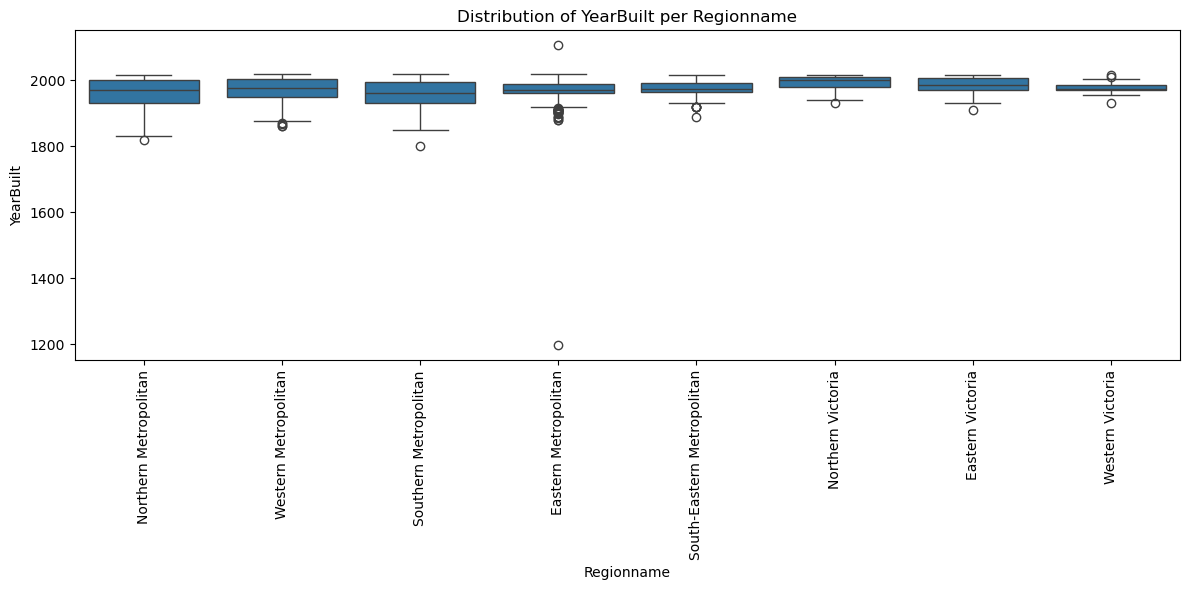

In [90]:
df_clean = MelbourneFullBaseDF.dropna(subset=['YearBuilt'])

plt.figure(figsize=(12, 6))

sns.boxplot(x='Regionname', y='YearBuilt', data=df_clean)
plt.title('Distribution of YearBuilt per Regionname')
plt.xlabel('Regionname')
plt.ylabel('YearBuilt')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Bovenstaande boxplots laten zien dat er wel degelijk een bepaalde verspreiding aanwezig is per regio die ook variëren van elkaar. Deze bevinding biedt de mogelijkheid om verder in te zoomen op de verschillende gemeentes binnenin de regio's.

Deze handeling biedt namelijk de mogelijkheid om te zien of er discrepanties in bouwjaar aanwezig zijn binnenin de regio, zodat er ook verder onderzocht kan worden of bepaalde wijken eenzelfde observatie bevatten.

Voor deze handeling zullen ook weer boxplots worden gecreëerd om de waardes per gebied te observeren.

<Figure size 1200x800 with 0 Axes>

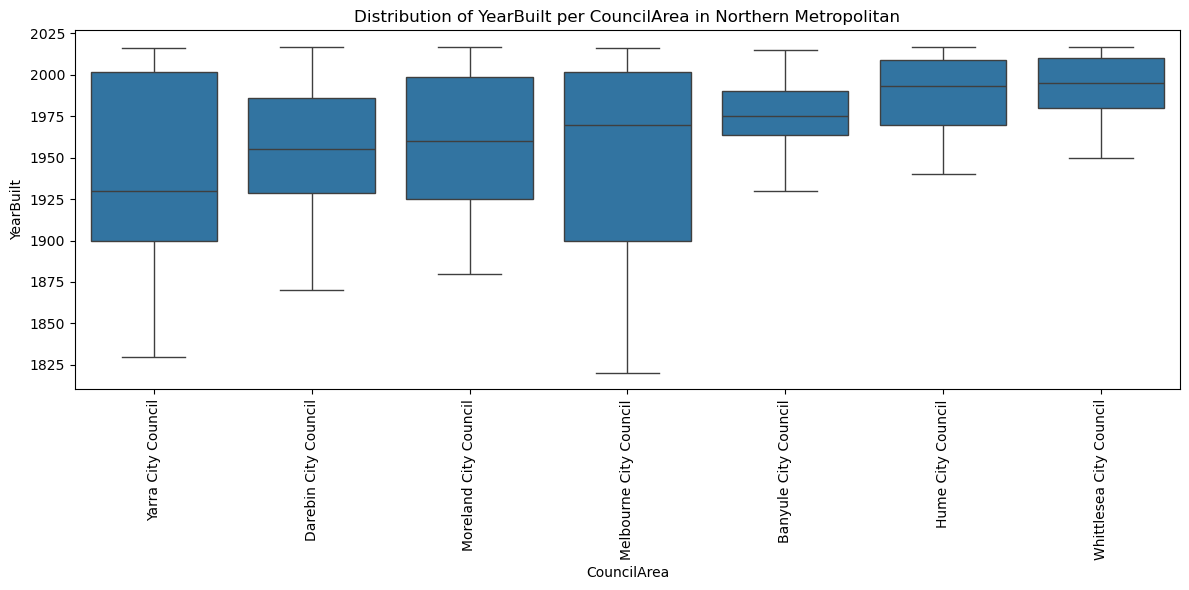

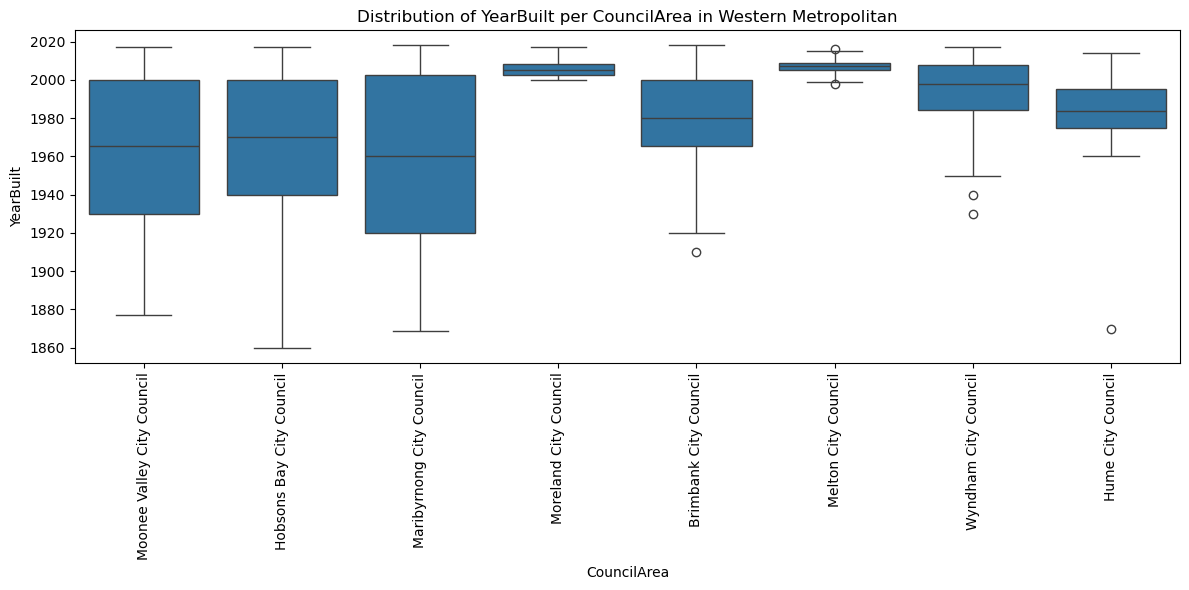

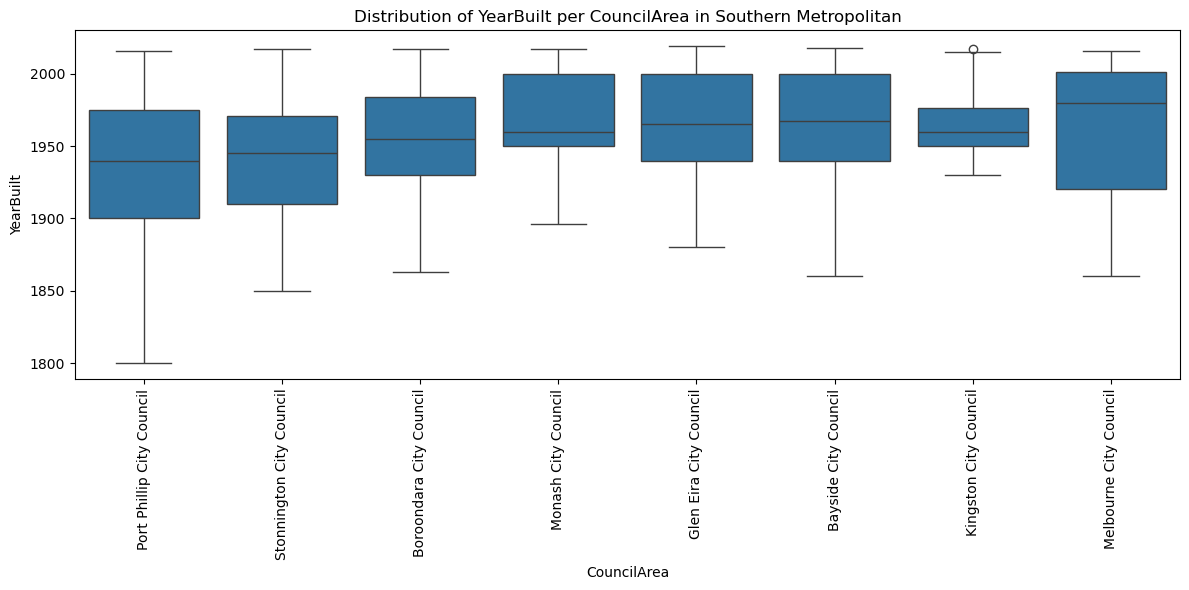

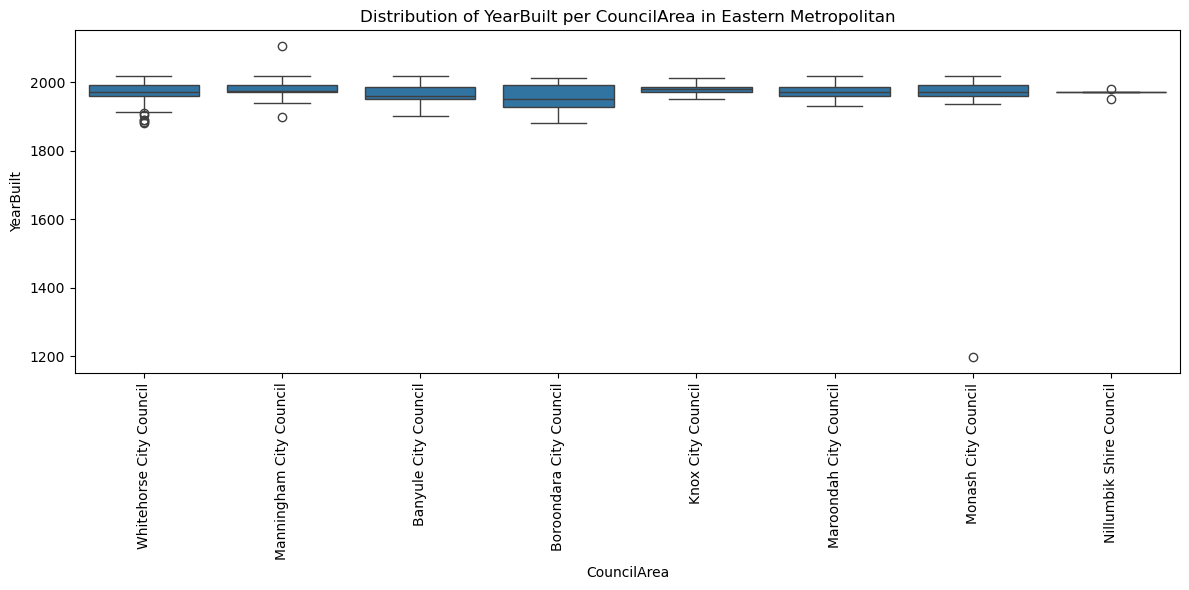

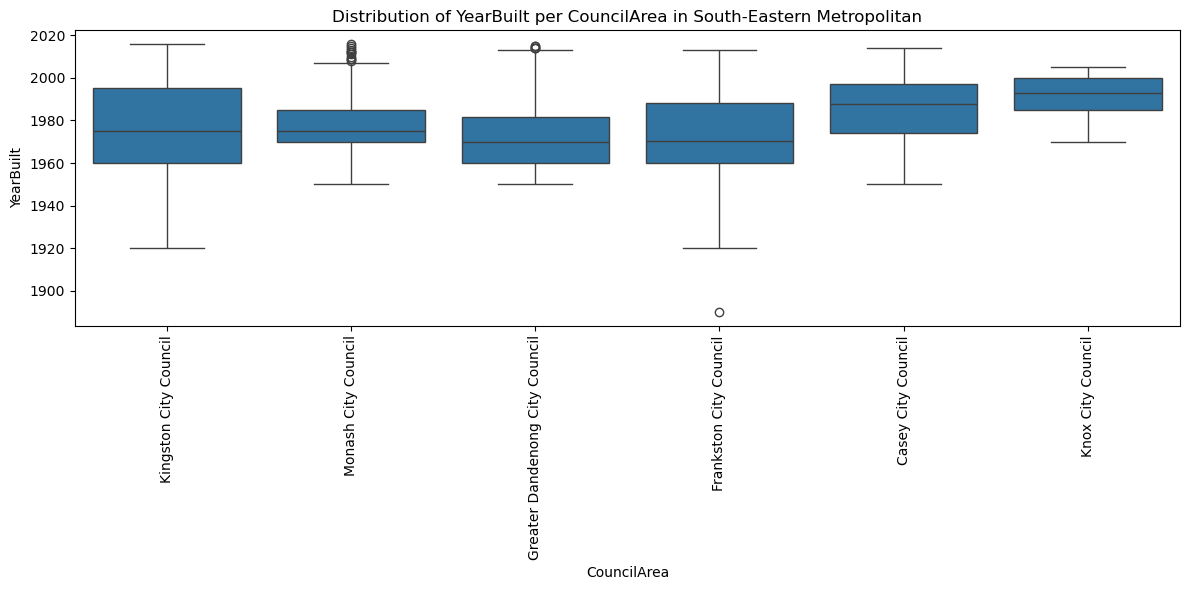

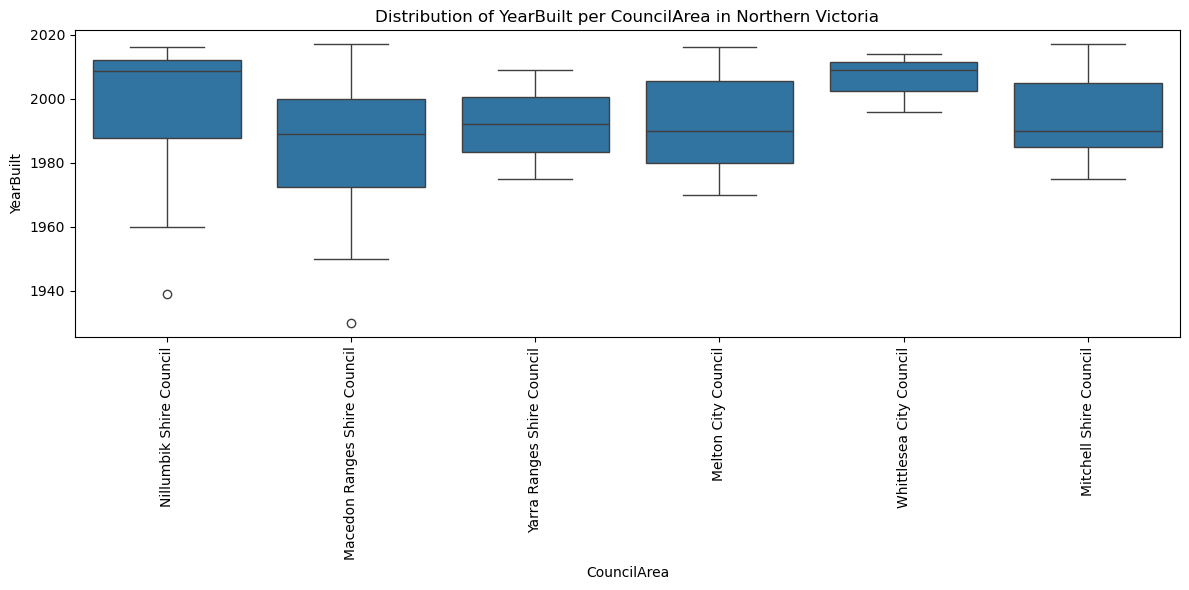

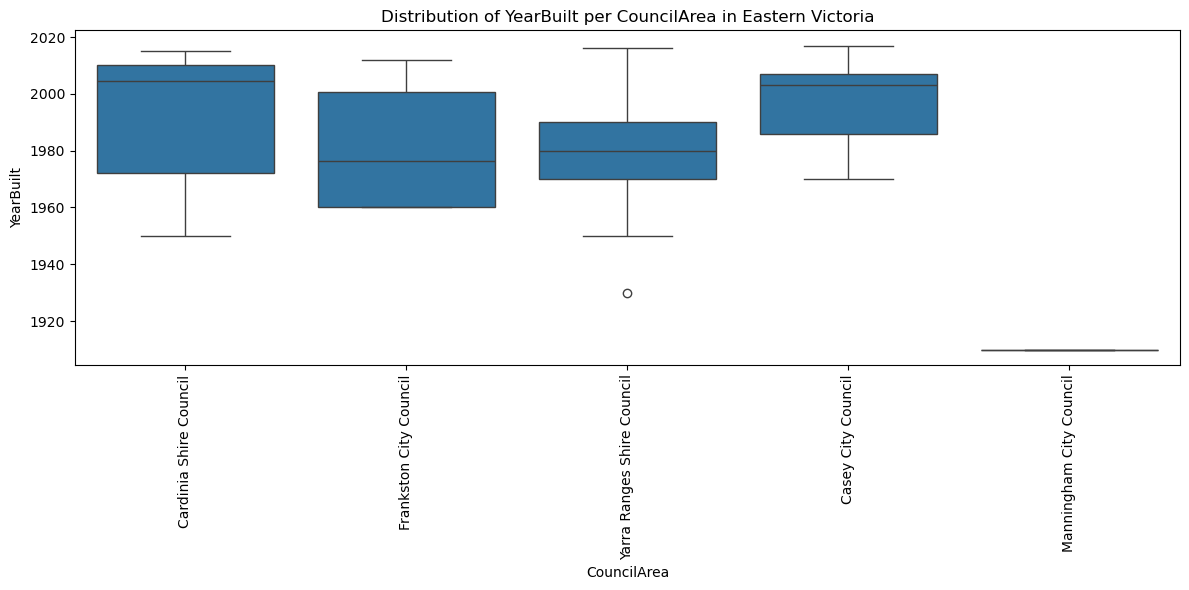

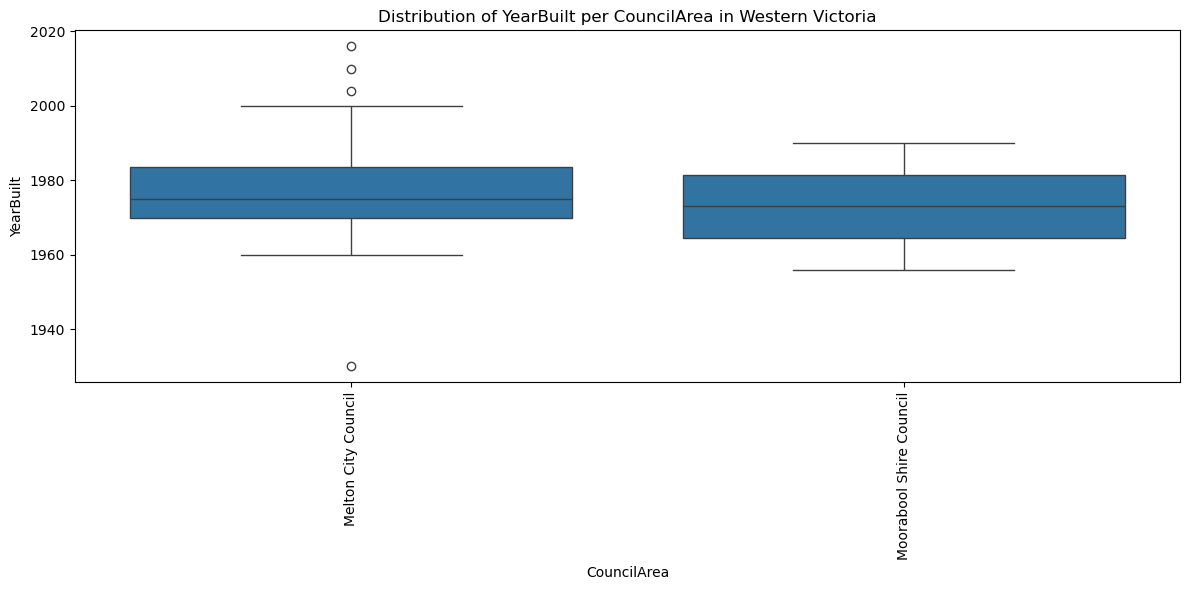

In [92]:
df_clean = MelbourneFullBaseDF.dropna(subset=['YearBuilt'])

regionnames = df_clean['Regionname'].unique()

plt.figure(figsize=(12, 8))

for region in regionnames:
    region_data = df_clean[df_clean['Regionname'] == region]
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='CouncilArea', y='YearBuilt', data=region_data)
    plt.title(f'Distribution of YearBuilt per CouncilArea in {region}')
    plt.xlabel('CouncilArea')
    plt.ylabel('YearBuilt')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Ook deze visualisaties laten zien dat er bepaalde unieke verspreidingen aanwezig zijn binnenin elke gemeente, al zijn er gemeentes met grotere verspreidingen. Omdat de verschillende wijken veel minder resultaten bevat zal deze verspreiding veel smaller worden, wat er voor zorgt dat er een specifieker resultaat geïmputeerd kan worden.

Er zijn te veel gemeentes om weer te geven, wat betekend dat er alleen voorbeelden worden gegeven, hiervoor worden er willekeurig vier verschillende plots weergegeven.

<Figure size 1200x1200 with 0 Axes>

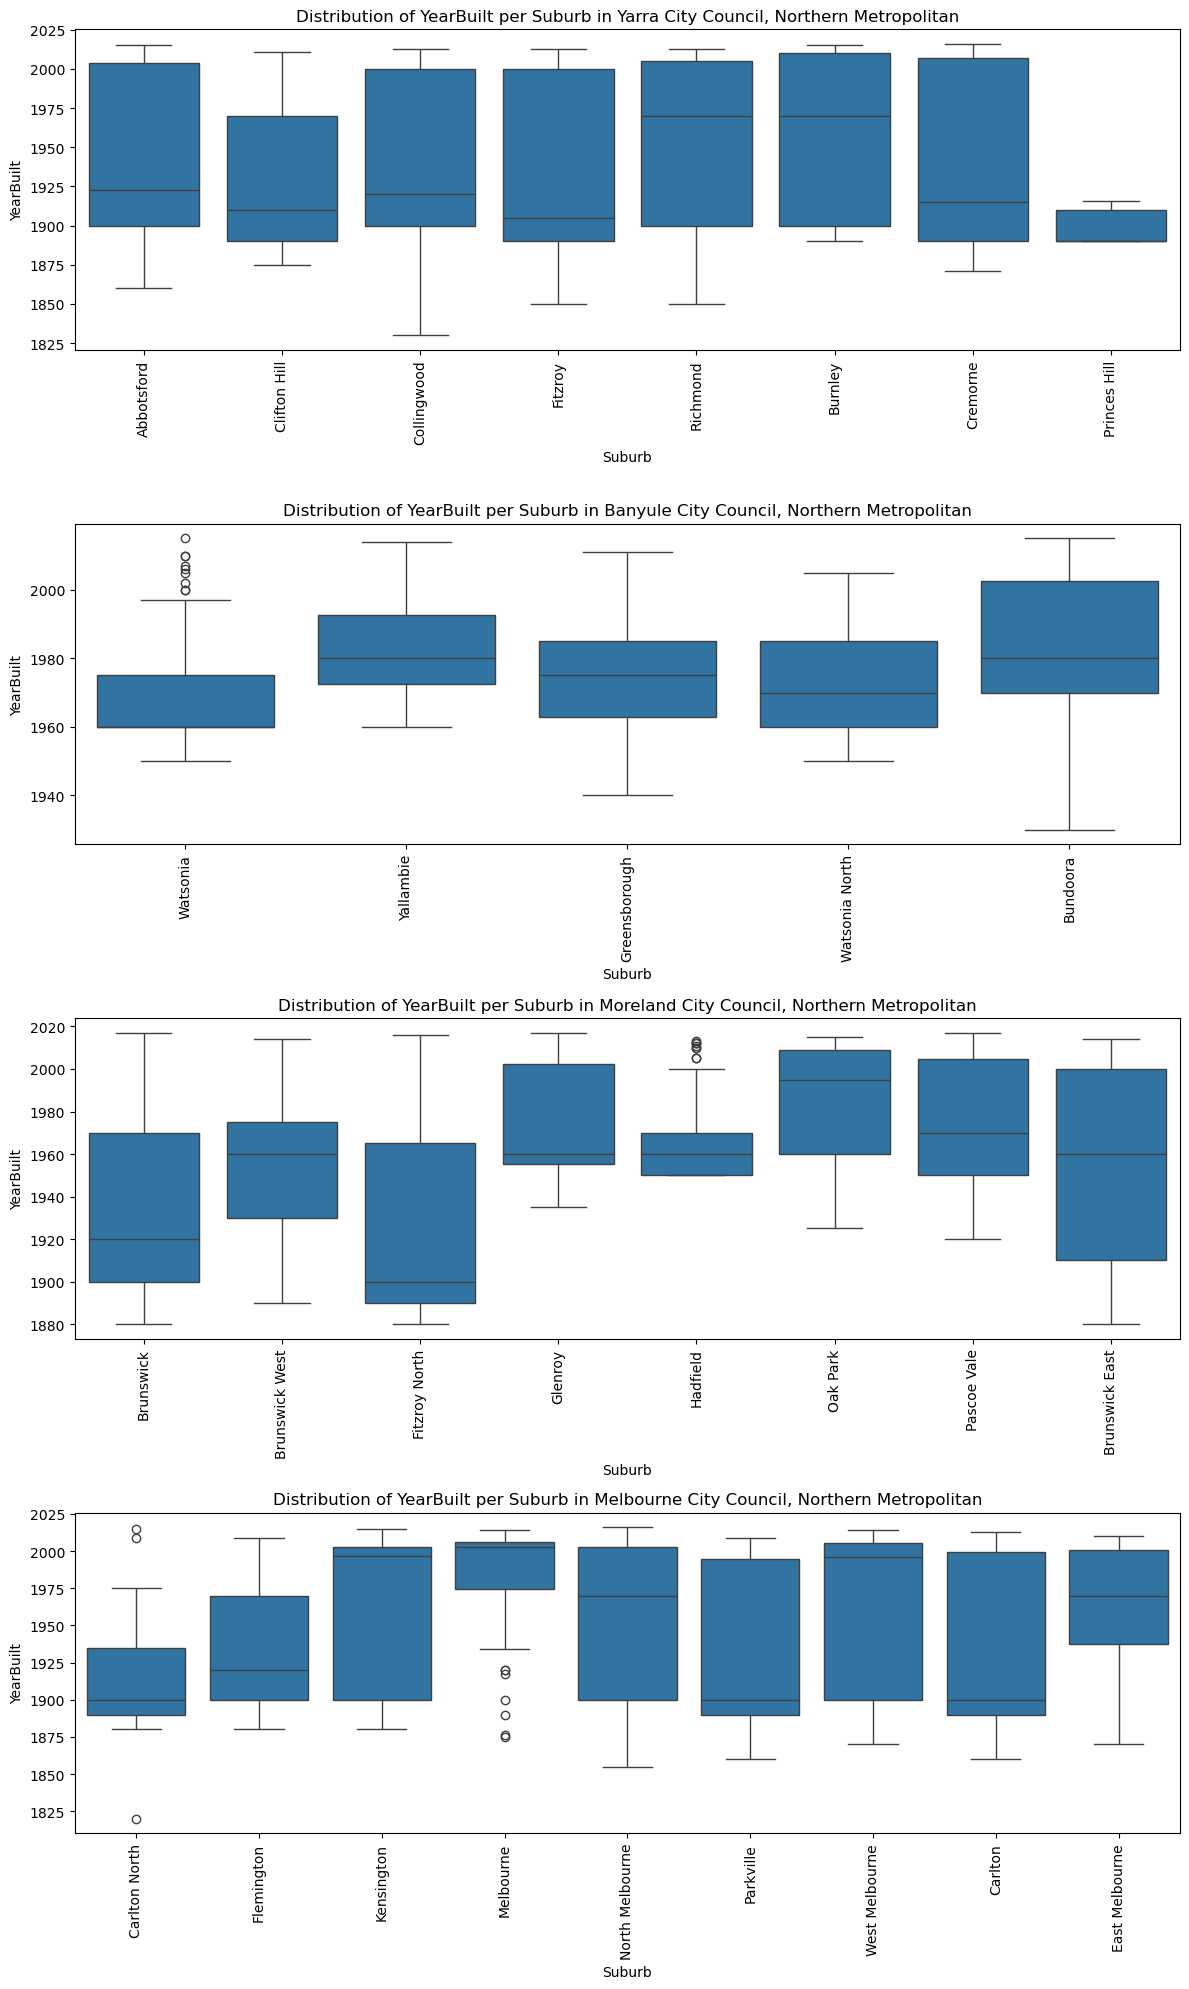

In [94]:
df_clean = MelbourneFullBaseDF.dropna(subset=['YearBuilt'])

regionnames = df_clean['Regionname'].unique()

plt.figure(figsize=(12, 12))

fig, axes = plt.subplots(4, 1, figsize=(12, 20))
axes = axes.flatten()

plot_idx = 0

for region in regionnames:
    region_data = df_clean[df_clean['Regionname'] == region]
    council_areas = region_data['CouncilArea'].unique()
    random_council_areas = random.sample(list(council_areas), 4)
    
    for council_area in random_council_areas:
        council_area_data = region_data[region_data['CouncilArea'] == council_area]
        sns.boxplot(x='Suburb', y='YearBuilt', data=council_area_data, ax=axes[plot_idx])
        axes[plot_idx].set_title(f'Distribution of YearBuilt per Suburb in {council_area}, {region}')
        axes[plot_idx].set_xlabel('Suburb')
        axes[plot_idx].set_ylabel('YearBuilt')
        axes[plot_idx].tick_params(axis='x', rotation=90)
        plot_idx += 1
        if plot_idx == 4:
            break

    if plot_idx == 4:
        break

plt.tight_layout()
plt.show()

Helaas valt er af te lezen dat er maar een aantal wijken zijn die een kleine verspreiding aan bouwjaar hebben, de meeste wijken lijken namelijk een verspreiding te hebben van een groot aantal jaren, wat het moeilijk maakt om een preciese waarde te imputeren.

Sommige boxplots hebben een verspreiding waaruit duidelijk naar voren komt dat de verdeling van de bouwjaren vooral hoog of laag ligt binnenin de respectieve wijk, maar een groot aantal boxplots hebben de waardes gewoonweg ongeveer in het midden liggen.

Om deze reden is het niet mogelijk om de imputatie-methode te gebruiken die voor de breedte- en lengtegraad is toegepast, in dat de verspreiding veel te groot is. Echter moeten de waardes toch in worden gevuld voor de toepassing van Regression op het bepalen van de woning prijs.

Om toch de waardes in te kunnen vullen, wordt een andere vorm van Machine Learning gebruikt voor de invulling van het bouwjaar. In principe is er nog steeds het idee dat woningen in een bepaalde wijk vaak eenzelfde soort huizen zijn, en dat daarbij eenzelfde bouwjaar hoort.

Omdat dit niet duidelijk naar voren komt wanneer alleen naar de wijk wordt gekeken, zal er verder gekeken worden naar de andere factoren binnenin de rijen. De Machine Learning methode die wordt toegepast, K-Nearest Neighbor, zal een bouwjaar invullen gebaseerd op overeenkomende factoren binnenin dezelfde wijk.

Deze Machine Learning zal dus later worden toegepast.

<b>BuildingArea</b>

De laatste kolom die nog moet worden ingevuld is BuildingArea. Zoals eerder is neergeschreven kan BuildingArea deels worden geïmputeerd op basis van andere factoren in de dataset zoals Landsize, Rooms, en Price.

In [96]:
train_data = MelbourneFullBaseDF.dropna(subset=["BuildingArea", "Price", "Rooms", "Landsize"]).copy()
 
X_train = train_data[["Rooms", "Landsize", "Price"]].copy()
y_train = train_data["BuildingArea"].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
 
regressor = LinearRegression()
regressor.fit(X_train_scaled, y_train)
 
missing_idx = MelbourneFullBaseDF[ (MelbourneFullBaseDF["BuildingArea"].isna()) & (MelbourneFullBaseDF["Price"].notna()) & (MelbourneFullBaseDF["Rooms"].notna()) & (MelbourneFullBaseDF["Landsize"].notna()) ].index
 
if not missing_idx.empty:
    X_missing = MelbourneFullBaseDF.loc[missing_idx, ["Rooms", "Landsize", "Price"]].copy()
    X_missing_scaled = scaler.transform(X_missing)
    MelbourneFullBaseDF.loc[missing_idx, "BuildingArea"] = regressor.predict(X_missing_scaled)
else:
    print("No rows with missing BuildingArea but complete predictors found.")

No rows with missing BuildingArea but complete predictors found.


<div id=section5>
<h2><b>Modelkeuze, Implementatie, en Evaluatie</b></h2>

Het doel van dit rapport is om te kunnen voorspellen wat een uiteindelijke prijs voor een woning kan zijn wanneer veel verschillende factoren worden geëvalueerd.

De prijs is een continue waarde die afhankelijk is van een lineaire relatie met andere waardes zoals de hoeveelheid land, het bouwjaar, en de hoeveelheid kamers. Deze relatie is redelijk lineair want er valt te verwachten dat een grotere hoeveelheid land of een ouder huis de prijs laat stijgen.

Echter zijn er ook variabelen die geen lineaire relatie kunnen hebben met de prijs, dit zijn categorische waardes die niet op die manier geïnterpreteerd kunnen worden. Waardes zoals de locatie en het type woning zullen zeker invloed hebben op de prijs, maar zijn niet toepasbaar op een Lineaire regressie model.

Tenslotte is er ook de ondervinding dat het logisch is dat bepaalde huizen op een bepaalde locatie, met dezelfde elementen vaak eenzelfde prijs zullen hebben, dit zou dan ook een manier kunnen zijn om een prijs te bepalen.

Deze manieren sluiten aan op de volgende algoritmes die geëvalueerd zullen worden voor gebruik met deze dataset:

- <b>Linear Regression</b>
- <b>Random Forest</b>
- <b>Support Vector Machines</b>
- <b>K-Nearest Neighbor</b>

Deze algoritmes zullen eerst kort worden omschreven in de vorm van voor- en nadelen, waarna er wordt uitgelegd hoe het model zal worden getraind, en welke hyperparameters mogelijk zijn voor installatie.

<b>Linear Regression</b>

De lineaire regressie is een simpel basismodel om prijzen te voorspellen gebaseerd op factoren die een lineaire relatie met de woning prijs hebben, voor dit model worden waardes zoals BuildingArea en YearBuilt gebruikt.

Dit model heeft de volgende voordelen:

- Het model is simpel en makkelijk te trainen.
- Het model is erg makkelijk te verklaren en onderbouwen gebaseerd op formules.
- Het model werkt goed wanneer de relaties lineair zijn.

Dit model heeft de volgende nadelen:

- Het model gaat uit van een lineaire relatie, die mogelijk niet aanwezig is.
- Het model is gevoelig voor Multicollineariteit, een observatie dat de verklarende variabelen een te sterk lineair verband hebben dat de coëfficiënt verslechterd.
- Het model is gevoelig voor uitschieters.

Het model wordt op de volgende manier getraind:

1. Datavoorbereiding

- Toepassing van One-Hot encoding voor de categorische waardes.
- Toepassing van een schaal op de numerieke waardes.
- Elementaire invulling van nog-steeds missende waardes.

2. Data Split

- Splitsing van dataset in een 80/20 verhouding, waarbij 80% van de dataset wordt gebruikt voor het trainen van de AI.

3. Model Training

- Gebruik van de Ordinary Least Squares training set, een training set die zich goed aansluit op lineaire regressie, in dat deze de waardes die bij de normale regressie formule horen in zijn geheel uitschrijft.

4. Evaluatie

- Evaluatiemetrieken in de vorm van (Root) Mean Squared Error en de R² Score.
- Een lage MSE betekend meer nauwkeurigheid dan een hoge MSE.
- Een R² Score die dicht bij 1 ligt houdt in dat het model grotendeels de variantie uit kan leggen, hoe minder deze score is, hoe minder patronen aanwezig zijn voor de lineaire regressie.
- Een grote discrepantie tussen de respectieve scores in de training en test set zouden een aanwijzing voor de aanwezigheid van Overfitting kunnen zijn.
- Wanneer de R² Scores voor de training en test set beiden laag zijn, maar de MSE voor beiden hoog is, kan er Underfitting aanwezig zijn.

5. Parameters

- Indien nodig, een weglating van overbodige kolommen.

De volgende stappen zullen deze training weergeven.

Allereerst is het belangrijk om te checken of alle datatypes nog correct zijn.

In [98]:
MelbourneFullBaseDF.dtypes

Suburb                   object
Address                  object
Rooms                     int64
Type                     object
Price                    object
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                 object
Bedroom2                float64
Bathroom                float64
Car                       int64
Landsize                 object
BuildingArea             object
YearBuilt                object
CouncilArea              object
Latitude                float64
Longitude               float64
Regionname               object
Propertycount           float64
Difference               object
dtype: object

Er is te zien dat Landsize, BuildingArea, YearBuilt, en de nieuwe aangemaakte kolom "Difference" allemaal een object als datatype hebben omdat dit niet terug was geconverteerd na onze imputatie. Dit zal dan nu moeten gebeuren.

In [100]:
MelbourneFullBaseDF['Landsize'] = pd.to_numeric(MelbourneFullBaseDF['Landsize'], errors='coerce').astype('float64')
MelbourneFullBaseDF['BuildingArea'] = pd.to_numeric(MelbourneFullBaseDF['BuildingArea'], errors='coerce').astype('float64')
MelbourneFullBaseDF['Difference'] = pd.to_numeric(MelbourneFullBaseDF['Difference'], errors='coerce').astype('float64')
MelbourneFullBaseDF['YearBuilt'] = pd.to_numeric(MelbourneFullBaseDF['YearBuilt'], errors='coerce').astype('float64')

print(MelbourneFullBaseDF.dtypes)

Suburb                   object
Address                  object
Rooms                     int64
Type                     object
Price                    object
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                 object
Bedroom2                float64
Bathroom                float64
Car                       int64
Landsize                float64
BuildingArea            float64
YearBuilt               float64
CouncilArea              object
Latitude                float64
Longitude               float64
Regionname               object
Propertycount           float64
Difference              float64
dtype: object


Nu dat alle kolommen weer het correcte datatype hebben, kan het stappenplan worden uitgevoerd. Beginnende met de voorbereiding van de data.

<b>Stap 1: Datavoorbereiding</b>

Eerst zullen de numerieke kolommen worden geselecteerd gebaseerd op de mogelijkheid dat er een lineaire regressie aan te tonen valt. Hierbij worden alle numerieke kolommen geselecteerd, behalve Longitude en Latitude, omdat deze zonder context niks toevoegen. Daarnaast bevat YearBuilt nog te veel missende waardes, en zal deze in een latere toepassing pas worden geïntegreerd in het model.

Ook belangrijk is de toepassing van One-Hot encoding op de categorische kolommen, de categorische kolommen die voor de voorspelling een toevoeging kunnen hebben zijn als volgt:

- Type
- CouncilArea
- Method
- Suburb
- Regionname

Tenslotte zijn er nog kolommen die belangrijk zijn voor de regressie maar toch nog data missen, waaronder de oppervlakte kolommen. Deze kolommen zullen elementair worden ingevuld gebaseerd op een simpele imputatie.

Daarnaast mist de Prijs kolom ongeveer 20% van de data, maar deze zullen dan worden gebruikt voor de test set.

In [102]:
df_imputed = MelbourneFullBaseDF.copy()

features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea']
categorical_features = ['Suburb', 'Type', 'Regionname', 'Method', 'CouncilArea']
target = 'Price'

columns_to_impute = ['BuildingArea', 'Landsize']
imputer = SimpleImputer(strategy='mean')
df_imputed[columns_to_impute] = imputer.fit_transform(df_imputed[columns_to_impute])

df_encoded = pd.get_dummies(df_imputed[features + categorical_features], drop_first=True)

<b>Stap 2: Data Split</b>

De volgende stap betreft het splitsen van de data, hiervoor zullen alle rijen met missende waardes voor Prijs gebruikt worden in een latere test set. Om dit te doen moeten deze eerst uitgelicht worden.

Daarna zullen de waardes binnenin de training data 80/20 worden gesplitst.

In [104]:
train_valid_df = df_imputed.dropna(subset=['Price'])
test_df = df_imputed[df_imputed['Price'].isna()]

print("Training + Validation Set Size:", train_valid_df.shape)
print("Test Set (Without Price) Size:", test_df.shape)

X = df_encoded.loc[train_valid_df.index]
y = train_valid_df['Price']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set Size:", X_train.shape)
print("Validation Set Size:", X_valid.shape)

Training + Validation Set Size: (27247, 22)
Test Set (Without Price) Size: (7610, 22)
Training Set Size: (21797, 406)
Validation Set Size: (5450, 406)


In bovenstaande print is te zien dat er 384 extra kolommen zijn toegevoegd doormiddel van de One-Hot Encoding.

<b>Stap 3: Model Training</b>

De volgende stap betreft de training van het model, hiervoor wordt een methode toegepast die het beste past bij de lineaire regressie in de vorm van Ordinary Least Sqaures (OLS).

Dit model zal een samenvatting genereren waaruit voortkomt hoe sterk elke relatie met de woonprijs is. Deze samenvatting bevat informatie over de volgende data:

- Coëfficiënten: De invloed van elke kolom op de woonprijs.
- P-waardes: De waarschijnlijkheid dat de prijs daadwerkelijk kan worden verklaard door de kolommen.
- Determinatiecoëfficiënt: De hoeveelheid van de woonprijs die kan worden verklaard door de kolommen.
- F-waardes: De validiteit van de regressielijn.

Allereerst zal nog worden gecheckt of de data geschikt is voor het model, in dat alles numeriek moet zijn, hiervoor zullen de kolommen met het object datatype weg worden gehaald nu dat deze One-Hot encoded zijn.

Ook zullen de TRUE en FALSE waardes van de One-Hot encoding worden omgezet naar numerieke waardes.

In [107]:
columns_to_remove = [
    'Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 
    'Postcode', 'CouncilArea', 'Regionname', 'Difference', 'YearBuilt'
]

X_train = X_train.drop(columns=columns_to_remove, errors='ignore')
X_valid = X_valid.drop(columns=columns_to_remove, errors='ignore')

y_train = pd.to_numeric(y_train, errors='coerce')
y_valid = pd.to_numeric(y_valid, errors='coerce')

In [108]:
boolean_columns = X_train.select_dtypes(include='bool').columns
X_train[boolean_columns] = X_train[boolean_columns].astype(int)
X_valid[boolean_columns] = X_valid[boolean_columns].astype(int)

In [109]:
X_train_with_const = sm.add_constant(X_train)
X_valid_with_const = sm.add_constant(X_valid)

In [110]:
ols_model = sm.OLS(y_train, X_train_with_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     120.9
Date:                Thu, 03 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:33:08   Log-Likelihood:            -3.1039e+05
No. Observations:               21797   AIC:                         6.215e+05
Df Residuals:                   21445   BIC:                         6.243e+05
Df Model:                         351                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [111]:
y_train_pred = ols_model.predict(X_train_with_const)
y_valid_pred = ols_model.predict(X_valid_with_const)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_valid = mean_squared_error(y_valid, y_valid_pred)

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_valid = mean_absolute_error(y_valid, y_valid_pred)

print(f"Training MAE: {mae_train}")
print(f"Validation MAE: {mae_valid}")

rmse_train = np.sqrt(mse_train)
rmse_valid = np.sqrt(mse_valid)

print(f"Training MSE: {mse_train}, RMSE: {rmse_train}")
print(f"Validation MSE: {mse_valid}, RMSE: {rmse_valid}")

Training MAE: 234443.095886493
Validation MAE: 236833.97684700458
Training MSE: 136809145104.88457, RMSE: 369877.20273745526
Validation MSE: 153412704539.9141, RMSE: 391679.3389239648


<b>Stap 4: Evaluatie</b>

Eerder waren er een aantal formules aangegeven die het lineaire regressiemodel evalueren, deze zullen nogmaals uit worden gelicht in de context van het model.

<b>R² Score: 0.665</b>

Deze score geeft weer dat 66.4% van de variantie binnenin de huisprijzen verklaard kunnen worden door het model.

Huisprijzen zijn ontzettend afhankelijk van context die niet makkelijk kan worden neergeschreven binnenin data. Informatie zoals ligging, afstand van het centrum, misdaadcijfers, en biodiversiteit zijn allemaal factoren die ook invloed zullen hebben op de prijs van een huis, maar niet aanwezig zijn in deze dataset.

Deze score geeft weer dat een aantal belangrijke kolommen zoals BuildingArea en Rooms goed zijn opgenomen in het model, maar dat er andere factoren zijn die niet in het model zitten maar toch veel toedoen hebben op de huisprijzen.

Daarnaast zijn er mogelijk kolommen die totaal geen lineaire relatie met woonprijs hebben maar toch zijn geïnterpreteerd op deze manier, deze kolommen zullen daardoor ook niet in het model passen.

<b>Adj, R² Score: 0.659</b>

Deze score geeft de R² Score weer wanneer alleen voorspellers die een toedoen hebben op het model worden overwogen.

Gezien het verschil tussen de twee scores erg minimaal is, kan er van uit worden gegaan dat de meeste voorspellers een invloed hebben op de huisprijs, maar dat er een klein aantal kolommen zijn die totaal geen invloed hebben op het model. Dit kunnen bijvoorbeeld bepaalde suburbs zijn die te weinig data bevatten.

<b>F-waarde: 121.2</b>

De hoge F-waarde insinueerd dat er een aantal kolommen zijn die het model positief beïnvloeden, en dat deze kolommen ervoor zorgen dat de woning prijs accuraat kan worden voorspeld.

Dit betekend niet dat het model perfect is, maar dat er tenminste een kolom is die een groot deel van de woonprijs kan bepalen.

<b>P-waarde: 0.00</b>

Daarnaast is de P-waarde voor deze waarneming ontzettend laag, wat betekend dat er vrijwel geen mogelijkheid is dat alle kolommen geen invloed hebben op het model.

<b>MSE & RMSE</b>

De MSE waarde is moeilijk te interpreteren doordat de prijzen van huizen zo hoog zijn. Normaal gesproken is een hoge MSE een indicatie dat de voorspelling veel fouten kan bevatten, maar in dit geval is het moeilijk te bepalen of dit een hoge waarde is. Om deze toch te kunnen interpreteren wordt de RMSE gebruikt om een makkelijker cijfer aan te rijken.

De waarde voor RMSE is 391433.76, oftewel 391433,76 AUD.

Dit inzicht laat zien dat de voorspellingen met ongeveer 391K AUD afwijken van de daadwerkelijke prijs, wat in de context van huizen een redelijk grote afwijking is.

<b>Overfitting & Underfitting</b>

Uit de vergelijking tussen training en validatie waardes was af te lezen dat er een verschil aanwezig is:

Training MSE: 136802362043.41652, RMSE: 369868.03328135365
Validatie MSE: 153220389394.9584, RMSE: 391433.76118439046

Het verschil tussen de makkelijk te interpreteren data is ongeveer 21K AUD, wat in de context van de huizenmarkt niet een heel drastisch verschil is, echter kan het wel een insinuatie van overfitting op een kleine schaal zijn.

Ondanks het verschil zijn beiden waardes nog steeds erg groot in de context van deze dataset, wat een grotere indicatie van overfitting is.

Het is mogelijk dat er niet genoeg gevarieerde data aanwezig is die correct alle variabelen overweegt, en juist alleen de uitgebreide kolommen gebruikt.

<b>Stap 5: Parameters</b>

De bevindingen laten zien dat alle kolommen invloed hebben op de prijs van een woning, echter is er ook te zien dat het model niet geheel toepasbaar is. Een overweging in de vorm van parameters is om de verschillende wijken weg te laten, omdat er een heel aantal zijn die niet genoeg waardes bevatten om een positieve contributie te leveren.

<b>Random Forest</b>

Dit model heeft de volgende voordelen:

- Het model gaat niet alleen uit van lineaire relaties tussen kolommen.
- Het model werkt met missende waardes en categorische data.
- Het model bevat minder snel Overfitting

Dit model heeft de volgende nadelen:

- Het model is moeilijker te interpreteren dan Lineaire Regressie.

Omdat het vorige model al een trainingset klaar heeft staan waarin imputatie voorkomt, zal deze worden vergeleken met een trainingset zonder imputatie van de oppervlakte kolommen.

Het model wordt op de volgende manier getraind:

1. Datavoorbereiding

- Toepassing van One-Hot encoding voor de categorische waardes.
- Verwijdering van kolommen die niet te gebruiken zijn.
- Elementaire invulling van nog-steeds missende waardes.

2. Data Split

- Splitsing van dataset in een 80/20 verhouding, waarbij 80% van de dataset wordt gebruikt voor het trainen van de AI.

3. Model Training

- Gebruik van 150 bomen om de nauwkeurigheid te verbeteren.

4. Evaluatie

- Evaluatiemetriek in de vorm van de Out-of-Bag score (OOB).
- Evaluatiemetriek in de vorm van MSE en RMSE.
- Een hoge OOB-score betekend dat het model een goed past bij de dataset.

5. Parameters

- Indien nodig kunnen meer bomen worden gebruikt.
- Limiet instellen voor het aantal keren dat een splits in overwegingen voorkomt via "max_depth".
- Een standaard laten instellen voordat er verdere overwegingen worden gemaakt via "min_samples_split".
- Een standaard laten instellen als laatste conclusie voor het model via "min_samples_leaf"

De volgende stappen zullen deze training weergeven.

<b>Stap 1: Data Voorbereiding</b>

Er worden twee modellen gecreëerd om te vergelijken:

- Één model met de imputatie van oppervlakte kolommen.
- Één model zonder de imputatie van oppervlakte kolommen.

Ook deze modellen worden gesplitst 80/20.

In [113]:
MelbourneRF_ImputedDF = MelbourneFullBaseDF.copy()

features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea']
categorical_features = ['Suburb', 'Type', 'Regionname', 'Method', 'CouncilArea']
target = 'Price'

columns_to_impute = ['BuildingArea', 'Landsize']
imputer = SimpleImputer(strategy='mean')
MelbourneRF_ImputedDF[columns_to_impute] = imputer.fit_transform(MelbourneRF_ImputedDF[columns_to_impute])

RF_Encoded_Imputed = pd.get_dummies(MelbourneRF_ImputedDF[features + categorical_features], drop_first=True)

train_valid_rf = MelbourneRF_ImputedDF.dropna(subset=['Price'])

X_rf = RF_Encoded_Imputed.loc[train_valid_rf.index]
y_rf = train_valid_rf['Price']

X_rf_train, X_rf_valid, y_rf_train, y_rf_valid = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

print("Training Set Size (With Imputation):", X_rf_train.shape)
print("Validation Set Size (With Imputation):", X_rf_valid.shape)

Training Set Size (With Imputation): (21797, 406)
Validation Set Size (With Imputation): (5450, 406)


In [114]:
MelbourneRF_NoImputeDF = MelbourneFullBaseDF.copy()

RF_Encoded_NoImpute = pd.get_dummies(MelbourneRF_NoImputeDF[features + categorical_features], drop_first=True)

train_valid_rf_no_impute = MelbourneRF_NoImputeDF.dropna(subset=['Price'])

X_rf_no_impute = RF_Encoded_NoImpute.loc[train_valid_rf_no_impute.index]
y_rf_no_impute = train_valid_rf_no_impute['Price']

X_rf_train_no_impute, X_rf_valid_no_impute, y_rf_train_no_impute, y_rf_valid_no_impute = train_test_split(
    X_rf_no_impute, y_rf_no_impute, test_size=0.2, random_state=42
)

print("Training Set Size (Without Imputation):", X_rf_train_no_impute.shape)
print("Validation Set Size (Without Imputation):", X_rf_valid_no_impute.shape)

Training Set Size (Without Imputation): (21797, 406)
Validation Set Size (Without Imputation): (5450, 406)


<b>Stap 2.1: Model 1 Training</b>

Voor beiden modellen zal dezelfde training worden uitgevoerd. Hierbij horen een training- en validatie simulatie, waarbij het model wordt toegepast op nieuwe data.

Bij dit model zal een aantal metrieken gegenereerd worden waaruit voortkomt hoe sterk het model bij de data past. Deze metrieken zijn als volgt:

- MSE: Het kwadratische verschil tussen de werkelijke en voorspellende waarde.
- RMSE: Wortel van de gemiddelde kwadratische fout.
- MAE: Het gemiddelde verschil tussen de werkelijke en voorspellende waarde.
- OOB-Score: De meting van de toepasbaarheid van het model op geheel nieuwe data.

Allereerst zal nog worden gecheckt of de data geschikt is voor het model, in dat alles numeriek moet zijn, hiervoor zullen de kolommen met het object datatype weg worden gehaald nu dat deze One-Hot encoded zijn.

Ook zullen de TRUE en FALSE waardes van de One-Hot encoding worden omgezet naar numerieke waardes.

In [116]:
rf_model_imputed = RandomForestRegressor(random_state=42, n_estimators=150, oob_score=True)
rf_model_imputed.fit(X_rf_train, y_rf_train)

y_rf_train_pred = rf_model_imputed.predict(X_rf_train)
y_rf_valid_pred = rf_model_imputed.predict(X_rf_valid)

mse_rf_train = mean_squared_error(y_rf_train, y_rf_train_pred)
rmse_rf_train = np.sqrt(mse_rf_train)
mae_rf_train = mean_absolute_error(y_rf_train, y_rf_train_pred)

mse_rf_valid = mean_squared_error(y_rf_valid, y_rf_valid_pred)
rmse_rf_valid = np.sqrt(mse_rf_valid)
mae_rf_valid = mean_absolute_error(y_rf_valid, y_rf_valid_pred)

oob_score_rf_imputed = rf_model_imputed.oob_score_

print(f"Training MSE (Met Imputatie): {mse_rf_train}")
print(f"Training RMSE (Met Imputatie): {rmse_rf_train}")
print(f"Training MAE (Met Imputatie): {mae_rf_train}")
print(f"Validatie MSE (Met Imputatie): {mse_rf_valid}")
print(f"Validatie RMSE (Met Imputatie): {rmse_rf_valid}")
print(f"Validatie MAE (Met Imputatie): {mae_rf_valid}")
print(f"OOB Score (Met Imputatie): {oob_score_rf_imputed}")

Training MSE (Met Imputatie): 17021380488.583418
Training RMSE (Met Imputatie): 130466.01277184575
Training MAE (Met Imputatie): 73605.17125882408
Validatie MSE (Met Imputatie): 100140023955.0639
Validatie RMSE (Met Imputatie): 316449.0858812266
Validatie MAE (Met Imputatie): 178714.39274219755
OOB Score (Met Imputatie): 0.7513157390272297


<b>Stap 2.2: Model 2 Training</b>

In [118]:
rf_model_no_impute = RandomForestRegressor(random_state=42, n_estimators=150, oob_score=True)
rf_model_no_impute.fit(X_rf_train_no_impute, y_rf_train_no_impute)

y_rf_train_pred_no_impute = rf_model_no_impute.predict(X_rf_train_no_impute)
y_rf_valid_pred_no_impute = rf_model_no_impute.predict(X_rf_valid_no_impute)

mse_rf_train_no_impute = mean_squared_error(y_rf_train_no_impute, y_rf_train_pred_no_impute)
rmse_rf_train_no_impute = np.sqrt(mse_rf_train_no_impute)
mae_rf_train_no_impute = mean_absolute_error(y_rf_train_no_impute, y_rf_train_pred_no_impute)

mse_rf_valid_no_impute = mean_squared_error(y_rf_valid_no_impute, y_rf_valid_pred_no_impute)
rmse_rf_valid_no_impute = np.sqrt(mse_rf_valid_no_impute)
mae_rf_valid_no_impute = mean_absolute_error(y_rf_valid_no_impute, y_rf_valid_pred_no_impute)

oob_score_rf_no_impute = rf_model_no_impute.oob_score_

print(f"Training MSE (Zonder Imputation): {mse_rf_train_no_impute}")
print(f"Training RMSE (Zonder Imputation): {rmse_rf_train_no_impute}")
print(f"Training MAE (Zonder Imputation): {mae_rf_train_no_impute}")
print(f"Validatie MSE (Zonder Imputation): {mse_rf_valid_no_impute}")
print(f"Validatie RMSE (Zonder Imputation): {rmse_rf_valid_no_impute}")
print(f"Validatie MAE (Zonder Imputation): {mae_rf_valid_no_impute}")
print(f"OOB Score (Zonder Imputation): {oob_score_rf_no_impute}")

Training MSE (Zonder Imputation): 17692113670.764153
Training RMSE (Zonder Imputation): 133011.7050141233
Training MAE (Zonder Imputation): 74929.15704599213
Validatie MSE (Zonder Imputation): 98621702401.35243
Validatie RMSE (Zonder Imputation): 314040.924723757
Validatie MAE (Zonder Imputation): 177305.50144392095
OOB Score (Zonder Imputation): 0.7525924304755336


<b>Stap 3: Evaluatie</b>

Bovenstaande inzichten geven de verschillende metrieken weer die gemeten zijn, deze worden vergeleken om te zien in hoeverre de data past bij het model.

<b>MSE</b>

In de training simulatie was de prestatie van het model zonder imputatie een klein beetje minder dan met imputatie. Echter was het in de validatie simulatie juist sterker zonder imputatie dan met imputatie.

Dit betekend dat het model beter presteert op geheel nieuwe data dan op de bestaande data, wat kan suggereren dat de imputatie heeft gezorgd voor overfitting.

<b>RMSE</b>

Dezelfde observatie is te zien binnenin het bepalen van de RMSE, in de training simulatie komt het model wat slechter naar buiten wanneer er geen imputatie aanwezig is, maar komt juist sterker naar buiten binnenin de validatie simulatie.

Ook deze observatie insinueerd de aanwezigheid van overfitting.

<b>MAE</b>

Ook bij deze metriek is dezelfde observatie af te lezen. Wat meer kracht geeft aan de insinuatie dat de imputatie mogelijk heeft gezorgd voor overfitting.

<b>OOB Score</b>

Tenslotte laten deze observaties zich zien in de berekening van de OOB-score. Deze OOB-score laat zien dat het model beter werkt wanneer er geen imputatie aanwezig is.

Ondanks het feit dat alle bevindingen erg klein zijn, is het duidelijk dat de simpele imputatie die uit is gevoerd een negatieve invloed heeft gehad op het model, en dat deze mogelijk voor overfitting heeft gezorgd.

<b>Stap 4: Parameters</b>

Indien dit model verder gebruikt gaat worden zijn een aantal parameters te bedenken om de data goed te laten aansluiten op het model:

- Max_Depth verhogen om overfitting te minimaliseren.
- min_samples_leaf verhogen om overfitting te minimaliseren.

Deze parameters zouden ervoor zorgen dat de overfitting wordt verminderd, wat een consistent probleem was in de metrieken.

<b>Support Vector Machines</b>

SVM is een model dat gebruikt kan worden om regressie toe te passen waarmee de woning prijs voorspelt kan worden.

Dit model heeft de volgende voordelen:

- Het model werkt goed met veel kolommen.
- Het model bevat minder snel Overfitting

Dit model heeft de volgende nadelen:

- Het model is moeilijker te gebruiken met een rommelige dataset.

Het model heeft eenzelfde toepassing als de lineaire regressie, wat betekend dat eenzelfde handelingen moeten worden uitgevoerd.

Het model wordt op de volgende manier getraind:

1. Datavoorbereiding

- Toepassing van One-Hot encoding voor de categorische waardes.
- Verwijdering van kolommen die niet te gebruiken zijn.
- Elementaire invulling van nog-steeds missende waardes.

2. Data Split

- Splitsing van dataset in een 80/20 verhouding, waarbij 80% van de dataset wordt gebruikt voor het trainen van de AI.

3. Model Training

- Toepassing van het SVM algoritme.

4. Evaluatie

- Evaluatiemetriek in de vorm van MAE.
- Evaluatiemetriek in de vorm van MSE en RMSE.
- Evaluatiemetriek in de vorm van R²-score.

- Een hoge waarde voor C of gamma kan overfitting insinueren.
- Een lage waarde voor C of gamma kan underfitting insinueren.

5. Parameters

- De C parameter kan worden aangepast om het besluit van de grenzen te versterken of verminderen.
- De gamma parameter kan worden aangepast om het aantal data te beperken of uit te breiden.

De volgende stappen zullen deze training weergeven.

<b>Stap 1: Data Voorbereiding</b>

In [121]:
df_copy = MelbourneFullBaseDF.copy()

columns_to_impute = ['BuildingArea', 'Landsize']
imputer = SimpleImputer(strategy='mean')

df_copy[columns_to_impute] = imputer.fit_transform(df_copy[columns_to_impute])

features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea']
categorical_features = ['Suburb', 'Type', 'Regionname', 'Method', 'CouncilArea']
target = 'Price'

df_encoded_svm = pd.get_dummies(df_copy[features + categorical_features], drop_first=True)

train_valid_df_svm = df_copy.dropna(subset=[target])
test_df_svm = df_copy[df_copy[target].isna()]

X_svm = df_encoded_svm.loc[train_valid_df_svm.index]
y_svm = train_valid_df_svm[target]

X_train_svm, X_valid_svm, y_train_svm, y_valid_svm = train_test_split(X_svm, y_svm, test_size=0.2, random_state=42)

print("Training Set Grootte (SVM):", X_train_svm.shape)
print("Validatie Set Grootte (SVM):", X_valid_svm.shape)

columns_to_remove = [
    'Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 
    'Postcode', 'CouncilArea', 'Regionname', 'Difference', 'YearBuilt'
]

X_train_svm = X_train_svm.drop(columns=columns_to_remove, errors='ignore')
X_valid_svm = X_valid_svm.drop(columns=columns_to_remove, errors='ignore')

y_train_svm = pd.to_numeric(y_train_svm, errors='coerce')
y_valid_svm = pd.to_numeric(y_valid_svm, errors='coerce')

boolean_columns_svm = X_train_svm.select_dtypes(include='bool').columns
X_train_svm[boolean_columns_svm] = X_train_svm[boolean_columns_svm].astype(int)
X_valid_svm[boolean_columns_svm] = X_valid_svm[boolean_columns_svm].astype(int)

non_numeric_columns_svm = X_train_svm.select_dtypes(exclude=['int64', 'float64']).columns
X_train_svm[non_numeric_columns_svm] = X_train_svm[non_numeric_columns_svm].astype(int)
X_valid_svm[non_numeric_columns_svm] = X_valid_svm[non_numeric_columns_svm].astype(int)

Training Set Grootte (SVM): (21797, 406)
Validatie Set Grootte (SVM): (5450, 406)


<b>Stap 2: Model Training</b> (Cell Executie duurt 6 minuten!!)

In [123]:
svm_model = SVR(kernel='linear', C=100, epsilon=0.1)

svm_model.fit(X_train_svm, y_train_svm)

y_pred_train_svm = svm_model.predict(X_train_svm)
y_pred_valid_svm = svm_model.predict(X_valid_svm)

mse_train_svm = mean_squared_error(y_train_svm, y_pred_train_svm)
rmse_train_svm = np.sqrt(mse_train_svm)

mse_valid_svm = mean_squared_error(y_valid_svm, y_pred_valid_svm)
rmse_valid_svm = np.sqrt(mse_valid_svm)

mae_train_svm = mean_absolute_error(y_train_svm, y_pred_train_svm)
mae_valid_svm = mean_absolute_error(y_valid_svm, y_pred_valid_svm)

print(f"Training MSE (SVM): {mse_train_svm}")
print(f"Training RMSE (SVM): {rmse_train_svm}")
print(f"Training MAE (SVM): {mae_train_svm}")
print(f"Validatie MSE (SVM): {mse_valid_svm}")
print(f"Validatie RMSE (SVM): {rmse_valid_svm}")
print(f"Validatie MAE (SVM): {mae_valid_svm}")

Training MSE (SVM): 218400290331.14053
Training RMSE (SVM): 467333.1684474584
Training MAE (SVM): 277452.4218511532
Validatie MSE (SVM): 240916090628.67807
Validatie RMSE (SVM): 490832.03912201786
Validatie MAE (SVM): 279962.6219602341


<b>Stap 3: Evaluatie</b>

Bovenstaande inzichten geven de verschillende metrieken weer die gemeten zijn, deze worden vergeleken om te zien in hoeverre de data past bij het model.

<b>MSE</b>

In de training simulatie was de prestatie van het model beter dan de prestatie in de validatie.

Dit suggereert dat het model beter presteert op de bestaande data dan op nieuwe data, wat geen positieve indicatie is voor toekomstig gebruik van het model.

<b>RMSE</b>

Dezelfde observatie is te zien binnenin het bepalen van de RMSE, in de validatie simulatie komt het model slechter naar voren dan binnenin de validatie simulatie.

Ook deze observatie insinueerd dat het model niet geschikt is voor toekomstig gebruik.

<b>MAE</b>

Tenslotte is ook de MAE in de training simulatie beter dan in de validatie simulatie.

<b>Overfitting en Underfitting</b>

Het feit dat alle scores zo hoog liggen kan insinueren dat er underfitting aanwezig is. Het model is namelijk niet capabel om de complexe relaties binnenin de dataset correct te evalueren en toe te passen.

<b>Stap 4: Parameters</b>

Indien dit model verder gebruikt gaat worden zijn een aantal parameters te bedenken om de data goed te laten aansluiten op het model:

- De C parameter kan worden aangepast om het besluit van de grenzen te versterken of verminderen, al kan dit zorgen voor overfitting of nog meer underfitting.
- De gamma parameter kan worden aangepast om het aantal data te beperken of uit te breiden. Ook deze aanpassing kan zorgen voor overfitting of meer underfitting.

<b>K-Nearest Neighbor</b>

Dit model is een simpele toepassing die waardes baseerd op soortgelijke data binnenin de dataset.

Dit model heeft de volgende voordelen:

- Dit model heeft geen trainingproces nodig.
- Dit model werkt goed met niet-lineaire data.

Dit model heeft de volgende nadelen:

- Dit model is gevoelig voor onbelangrijke kolommen.
- Dit model is gevoelig voor datasets met te veel kolommen.

1. Datavoorbereiding

Voor dit model moeten missende waardes ingevuld zijn, wat betekend dat de simpele imputatie weer wordt toegepast.
One-Hot Encoding moet ook weer gebruikt worden om numerieke kolommen te krijgen.
De Booleans die ontstaan uit deze encoding moeten geconverteerd worden naar cijfers.
Onnodige kolommen worden verwijderd.

2. Data Split

Voor dit model zal er weer een 80/20 split worden toegepast.

3. Model Training

In het model wordt de K-parameter aangepast om te bepalen hoeveel data neighbors worden bekeken.

4. Evaluatie

- Evaluatiemetriek in de vorm van MSE.
- Evaluatiemetriek in de vorm van RMSE.
- Evaluatiemetriek in de vorm van MAE.

- Als de K-parameter te klein is kan er overfitting ontstaan.
- Als de K-parameter te groot is kan er underfitting ontstaan.

5. Parameters

- De K-parameter kan aangepast worden om het aantal data neighbors die in overweging worden genomen groter of kleiner te maken.

De volgende stappen zullen deze training weergeven.

<b>Stap 1: Data Voorbereiding</b>

Het proces is vrijwel hetzelfde als vorige keren, in dat encoding wordt toegepast, bepaalde kolommen worden weggehaald, en de booleans worden omgezet naar numerieke waardes.

In [126]:
MelbourneKNNDF = MelbourneFullBaseDF.copy()

columns_to_impute = ['BuildingArea', 'Landsize']
imputer = SimpleImputer(strategy='mean')
MelbourneKNNDF[columns_to_impute] = imputer.fit_transform(MelbourneKNNDF[columns_to_impute])

features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea']
categorical_features = ['Suburb', 'Type', 'Regionname', 'Method', 'CouncilArea']
target = 'Price'

df_knn_encoded = pd.get_dummies(MelbourneKNNDF[features + categorical_features], drop_first=True)

boolean_columns = df_knn_encoded.select_dtypes(include='bool').columns
df_knn_encoded[boolean_columns] = df_knn_encoded[boolean_columns].astype(int)

columns_to_remove = [
    'Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 
    'Postcode', 'CouncilArea', 'Regionname', 'Difference', 'YearBuilt'
]
df_knn_encoded = df_knn_encoded.drop(columns=columns_to_remove, errors='ignore')

train_valid_knn_df = MelbourneKNNDF.dropna(subset=['Price'])
X_knn = df_knn_encoded.loc[train_valid_knn_df.index]
y_knn = train_valid_knn_df['Price']

X_train_knn, X_valid_knn, y_train_knn, y_valid_knn = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_knn)
X_valid_knn = scaler.transform(X_valid_knn)

print("Training Set Size (KNN):", X_train_knn.shape)
print("Validation Set Size (KNN):", X_valid_knn.shape)

Training Set Size (KNN): (21797, 406)
Validation Set Size (KNN): (5450, 406)


<b>Stap 2: Model Training</b>

In [128]:
knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_knn, y_train_knn)

y_train_knn_pred = knn_model.predict(X_train_knn)
y_valid_knn_pred = knn_model.predict(X_valid_knn)

mse_train_knn = mean_squared_error(y_train_knn, y_train_knn_pred)
rmse_train_knn = np.sqrt(mse_train_knn)
mae_train_knn = mean_absolute_error(y_train_knn, y_train_knn_pred)

mse_valid_knn = mean_squared_error(y_valid_knn, y_valid_knn_pred)
rmse_valid_knn = np.sqrt(mse_valid_knn)
mae_valid_knn = mean_absolute_error(y_valid_knn, y_valid_knn_pred)

print(f"Training MSE (KNN): {mse_train_knn}")
print(f"Training RMSE (KNN): {rmse_train_knn}")
print(f"Training MAE (KNN): {mae_train_knn}")
print(f"Validation MSE (KNN): {mse_valid_knn}")
print(f"Validation RMSE (KNN): {rmse_valid_knn}")
print(f"Validation MAE (KNN): {mae_valid_knn}")

Training MSE (KNN): 79550303622.82246
Training RMSE (KNN): 282046.63377325115
Training MAE (KNN): 168284.61091893382
Validation MSE (KNN): 128201693180.39642
Validation RMSE (KNN): 358052.64023659483
Validation MAE (KNN): 208212.25196330273


<b>Stap 3: Evaluatie</b>

Bovenstaande inzichten geven de verschillende metrieken weer die gemeten zijn, deze worden vergeleken om te zien in hoeverre de data past bij het model.

<b>MSE</b>

In de training simulatie was de prestatie van het model beter dan de prestatie in de validatie.

Dit suggereert dat het model beter presteert op de bestaande data dan op nieuwe data, wat geen positieve indicatie is voor toekomstig gebruik van het model.

Dit suggereert ook dat er overfitting aanwezig is door het drastische verschil tussen de twee waardes.

<b>RMSE</b>

Dezelfde observatie is te zien binnenin het bepalen van de RMSE, in de validatie simulatie komt het model slechter naar voren dan binnenin de validatie simulatie.

Ook deze observatie insinueerd dat het model niet geschikt is voor toekomstig gebruik.

<b>MAE</b>

Tenslotte is ook de MAE in de training simulatie beter dan in de validatie simulatie.

<b>Overfitting en Underfitting</b>

Het feit dat alle scores in de validatie simulatie zo veel hoger liggen dan de waardes in de training simulatie insinueerd dat er sprake is van overfitting.

<b>Stap 4: Parameters</b>

Indien dit model verder gebruikt gaat worden zijn een aantal parameters te bedenken om de data goed te laten aansluiten op het model:

- De K parameter kan worden aangepast om het aantal data neighbors die in overweging worden genomen groter of kleiner te maken.

Dit concludeert de toepassing van de vier modellen, hieronder volgt een overzicht waarna deze oogopzicht worden geëvalueerd en er een model wordt gekozen voor verdere toepassing en optimalisatie.

<b><h2>Model Evaluatie</h2></b>

In [131]:
mae_data = {
    "Model": ["Linear", "Random Forest 1", "Random Forest 2 (Geen Imputatie)", "SVM", "KNN"],
    "Training MAE": [mae_train, mae_rf_train, mae_rf_train_no_impute, mae_train_svm, mae_train_knn],
    "Validatie MAE": [mae_valid, mae_rf_valid, mae_rf_valid_no_impute, mae_valid_svm, mae_valid_knn]
}

mae_df = pd.DataFrame(mae_data)
display(mae_df)

,Model,Training MAE,Validatie MAE
0,Linear,234443.095886,236833.976847
1,Random Forest 1,73605.171259,178714.392742
2,Random Forest 2 (Geen Imputatie),74929.157046,177305.501444
3,SVM,277452.421851,279962.621960
4,KNN,168284.610919,208212.251963


De volgende observaties zijn waar te nemen:

- Random Forest modellen hebben verreweg de beste performance wanneer het aankomt op de Training.
- Hierbij is het model met imputatie net wat beter dan het model zonder imputatie.
- De Lineaire Regressie en de SVM hebben verreweg de slechtste performance wanneer het aankomt op de Training.

- Random Forest modellen hebben ook de beste performance wanneer het aankomt op de Validatie.
- Hierbij is het model zonder de imputatie net wat beter dan het model met de imputatie.
- De Lineaire Regressie en de SVM hebben beiden nogmaals de slechtste performance wanneer het aankomt op de Validatie.

Deze bevindingen suggereren dat de dataset totaal niet geschikt is voor lineaire modellen.

Deze waarneming is ook beter te zien wanneer het verschil tussen de Training- en Validatie waardes wordt bekeken, waarna gezien kan worden dat de waardes voor de Lineaire modellen vrijwel niet veranderen.

In [133]:
mse_data = {
    "Model": ["Linear", "Random Forest 1", "Random Forest 2 (Geen Imputatie)", "SVM", "KNN"],
    "Training MSE": [mse_train, mse_rf_train, mse_rf_train_no_impute, mse_train_svm, mse_train_knn],
    "Validatie MSE": [mse_valid, mse_rf_valid, mse_rf_valid_no_impute, mse_valid_svm, mse_valid_knn]
}

mse_df = pd.DataFrame(mse_data)
display(mse_df)

,Model,Training MSE,Validatie MSE
0,Linear,1.368091e+11,1.534127e+11
1,Random Forest 1,1.702138e+10,1.001400e+11
2,Random Forest 2 (Geen Imputatie),1.769211e+10,9.862170e+10
3,SVM,2.184003e+11,2.409161e+11
4,KNN,7.955030e+10,1.282017e+11


De volgende observaties zijn waar te nemen:

- Random Forest modellen hebben verreweg de beste performance wanneer het aankomt op de Training.
- Hierbij is het model met imputatie net wat beter dan het model zonder imputatie.
- De Lineaire Regressie en de SVM hebben verreweg de slechtste performance wanneer het aankomt op de Training.

- Random Forest modellen hebben ook de beste performance wanneer het aankomt op de Validatie.
- Hierbij is het model zonder de imputatie net wat beter dan het model met de imputatie.
- De Lineaire Regressie en de SVM hebben beiden nogmaals de slechtste performance wanneer het aankomt op de Validatie.

Ook deze bevindingen suggereren dat de dataset totaal niet geschikt is voor lineaire modellen.

Ook deze waarneming is beter te zien wanneer het verschil tussen de Training- en Validatie waardes wordt bekeken, waarna gezien kan worden dat de waardes voor de Lineaire modellen vrijwel niet veranderen.

In [135]:
rmse_data = {
    "Model": ["Linear", "Random Forest 1", "Random Forest 2 (Geen Imputatie)", "SVM", "KNN"],
    "Training RMSE": [rmse_train, rmse_rf_train, rmse_rf_train_no_impute, rmse_train_svm, rmse_train_knn],
    "Validatie RMSE": [rmse_valid, rmse_rf_valid, rmse_rf_valid_no_impute, rmse_valid_svm, rmse_valid_knn]
}

rmse_df = pd.DataFrame(rmse_data)
display(rmse_df)

,Model,Training RMSE,Validatie RMSE
0,Linear,369877.202737,391679.338924
1,Random Forest 1,130466.012772,316449.085881
2,Random Forest 2 (Geen Imputatie),133011.705014,314040.924724
3,SVM,467333.168447,490832.039122
4,KNN,282046.633773,358052.640237


De volgende observaties zijn waar te nemen:

- Random Forest modellen hebben nogmaals verreweg de beste performance wanneer het aankomt op de Training.
- Hierbij is het model met imputatie net wat beter dan het model zonder imputatie.
- De Lineaire Regressie en de SVM hebben weer verreweg de slechtste performance wanneer het aankomt op de Training.

- Random Forest modellen hebben ook de beste performance wanneer het aankomt op de Validatie.
- Hierbij is het model zonder de imputatie net wat beter dan het model met de imputatie.
- De Lineaire Regressie en de SVM hebben beiden nogmaals de slechtste performance wanneer het aankomt op de Validatie.

Zoals is gezien in de vorige bevindingen suggereerd ook deze waarneming dat de dataset totaal niet geschikt is voor lineaire modellen.

Op basis van al deze waarnemingen zijn de volgende conclusies getrokken:

- De Lineaire Modellen zijn totaal niet geschikt voor deze dataset, wat suggereert dat de huisprijzen niet te voorspellen zijn gebaseerd op lineaire relaties met features.
- Het KNN Model is niet het beste model, maar is ook niet zo slecht als de lineaire modellen, waat suggereert dat bepaalde data die niet als nummers kunnen worden gebruikt ook belangrijk zijn voor het voorspellen van de woning prijs.
- De Random Forest Modellen scoren altijd het beste voor alle metrieken.
- Het model zonder toegepaste imputatie scoort net wat minder dan het model met imputatie in de Training, maar scoort net wat beter in de Validatie.

Omdat het <b>Random Forest Model zonder imputatie</b> beter scoort in de toepassing op nieuwe data, zal deze verder worden uitgelicht in de volgende onderdelen van het rapport.

<div id=section6>
<h2><b>Optimalisatie en Verbeteringen</b></h2>

Ondanks het feit dat het RF-model het beste werkt, zijn er nog steeds een heel aantal aanpassingen toe te passen die het model kunnen optimaliseren:

<b>Aanpassing van Hyperparameters</b>

In het gedeelte over Random Forest waren er een aantal parameters uitgelicht die de werking van de modellen beïnvloeden:

- Het aantal bomen
- Het aantal keren dat een splits in overwegingen voorkomt.
- De standaard instellen voor een overeenkomst tussen een aantal bomen voordat er verdere overwegingen worden gemaakt.
- De standaard instellen voor een overeenkomst tussen een aantal bomen voordat een laatste conclusie kan worden getrokken.

Doormiddel van het aanpassen van deze verschillende hyperparameters kan er een combinatie gevonden worden die het beste bij het model past.

De technieken die kunnen worden toegepast om deze combinatie van hyperparameters te vinden is het gebruik van Cross Validation. De Cross Validation functie genereerd een raster met hyperparameter combinaties die dan worden geëvalueerd.

Deze techniek werkt goed maar kan wel erg computationeel zijn wanneer het raster te groot is.

<b>Feature Selectie</b>

Ondanks het feit dat het Random Forest model werkt met rommelige datasets, is dit geen excuus om overbodige kolommen in het model te laten.

In veel modellen kwam naar voren dat er sprake is van overfitting, en dat deze vooral naar voren is gekomen door het aantal categorische kolommen die vrijwel geen positieve invloed hadden op het model.

Om deze reden kan het model geoptimaliseerd worden indien er een selectie wordt gemaakt van features die ook daadwerkelijk invloed hebben op de woning prijs.

De technieken die hiervoor kunnen worden toegepast zijn als volgt:

- Filter Methodes: Hiermee worden alleen kolommen gekozen op basis van statistische gegevens.
- Ingebouwde Methodes: Functie selectie binnenin het Random Forest model dat kolommen selecteerd op basis van statistische gegevens.

<b>Feature Engineering</b>

Zoals eerder is beschreven in de evaluatie van de modellen is de woning prijs niet lineair te bepalen, er zijn veel factoren die deze waarde beïnvloeden die niet persé te zien zijn in de data.

Met gebruik van Feature Engineering zouden er nieuwe features aangemaakt kunnen worden die een meningsvolle relatie met de woning prijs kunnen hebben.

Een voorbeeld hiervan is bijvoorbeeld de toepassing van Discretisatie op de oppervlakte kolommen. Deze kolommen bevatten veel numerieke waardes die soms uniek zijn, en daardoor voor veel dataverwerking zorgen. Wanneer deze data wordt opgesplits in bins, is het al veel makkelijker voor het model om relaties te leggen.

Een ander voorbeeld was al eerder benoemd in het rapport in de vorm van de ligging van de woning. De coördinaten van de woningen zijn bekend, en hiermee kan bijvoorbeeld de afstand van het stadscentrum of andere voorzieningen in kaart worden gebracht in de vorm van nieuwe kolommen.

De technieken die bij dit onderdeel horen zijn dus als volgt:

- Binning
- Creatie van features

<b>Aanpassing van Hyperparameters</b>

Techniek: Cross Validation

In [140]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_model_no_impute = RandomForestRegressor(random_state=42, oob_score=True)

grid_search = GridSearchCV(estimator=rf_model_no_impute, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

grid_search.fit(X_rf_train_no_impute, y_rf_train_no_impute)

best_params = grid_search.best_params_
print("Best Hyperparameters from GridSearchCV:", best_params)

best_rf_model = grid_search.best_estimator_

y_rf_train_pred_no_impute = best_rf_model.predict(X_rf_train_no_impute)
y_rf_valid_pred_no_impute = best_rf_model.predict(X_rf_valid_no_impute)

mse_rf_train_no_impute_tuned = mean_squared_error(y_rf_train_no_impute, y_rf_train_pred_no_impute)
rmse_rf_train_no_impute_tuned = np.sqrt(mse_rf_train_no_impute)
mae_rf_train_no_impute_tuned = mean_absolute_error(y_rf_train_no_impute, y_rf_train_pred_no_impute)

mse_rf_valid_no_impute_tuned = mean_squared_error(y_rf_valid_no_impute, y_rf_valid_pred_no_impute)
rmse_rf_valid_no_impute_tuned = np.sqrt(mse_rf_valid_no_impute)
mae_rf_valid_no_impute_tuned = mean_absolute_error(y_rf_valid_no_impute, y_rf_valid_pred_no_impute)

oob_score_rf_no_impute_tuned = best_rf_model.oob_score_

print(f"Training MSE (Zonder Imputation): {mse_rf_train_no_impute_tuned}")
print(f"Training RMSE (Zonder Imputation): {rmse_rf_train_no_impute_tuned}")
print(f"Training MAE (Zonder Imputation): {mae_rf_train_no_impute_tuned}")
print(f"Validatie MSE (Zonder Imputation): {mse_rf_valid_no_impute_tuned}")
print(f"Validatie RMSE (Zonder Imputation): {rmse_rf_valid_no_impute_tuned}")
print(f"Validatie MAE (Zonder Imputation): {mae_rf_valid_no_impute_tuned}")
print(f"OOB Score (Zonder Imputation): {oob_score_rf_no_impute_tuned}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Hyperparameters from GridSearchCV: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Training MSE (Zonder Imputation): 37137269392.330315
Training RMSE (Zonder Imputation): 133011.7050141233
Training MAE (Zonder Imputation): 110042.05858466333
Validatie MSE (Zonder Imputation): 94969812239.34935
Validatie RMSE (Zonder Imputation): 314040.924723757
Validatie MAE (Zonder Imputation): 174722.13124117156
OOB Score (Zonder Imputation): 0.7648071167307898


Deze waardes zullen nu vergeleken worden met de waardes uit het eerste model:

In [142]:
comparison_df = pd.DataFrame({
    "Metric": [
        "MSE (Training)",
        "RMSE (Training)",
        "MAE (Training)",
        "MSE (Validation)",
        "RMSE (Validation)",
        "MAE (Validation)",
        "OOB Score"
    ],
    "Original Model": [
        mse_rf_train_no_impute, 
        rmse_rf_train_no_impute, 
        mae_rf_train_no_impute,
        mse_rf_valid_no_impute, 
        rmse_rf_valid_no_impute, 
        mae_rf_valid_no_impute,
        oob_score_rf_no_impute
    ],
    "Tuned Model": [
        mse_rf_train_no_impute_tuned, 
        rmse_rf_train_no_impute_tuned, 
        mae_rf_train_no_impute_tuned,
        mse_rf_valid_no_impute_tuned, 
        rmse_rf_valid_no_impute_tuned, 
        mae_rf_valid_no_impute_tuned,
        oob_score_rf_no_impute_tuned
    ]
})

print(comparison_df)

              Metric  Original Model   Tuned Model
0     MSE (Training)    1.769211e+10  3.713727e+10
1    RMSE (Training)    1.330117e+05  1.330117e+05
2     MAE (Training)    7.492916e+04  1.100421e+05
3   MSE (Validation)    9.862170e+10  9.496981e+10
4  RMSE (Validation)    3.140409e+05  3.140409e+05
5   MAE (Validation)    1.773055e+05  1.747221e+05
6          OOB Score    7.525924e-01  7.648071e-01


De volgende waarnemingen zijn af te lezen:

- In het nieuwe model zijn de waardes in de Training omhoog gegaan, wat insinueerd dat er sprake kan zijn van underfitting.
- Het kan echter ook insinueren dat het model zich richt op generalisatie in plaats van het memorizeren en toepassen van de data.

- In de Validatie zijn de scores voor het nieuwe model beter dan voorheen, wat insinueerd dat de voorspellende kracht van het model een klein beetje beter is.
- De OOB-Score is ook gestegen wat inhoud dat het model sterker is dan voorheen en beter tegen overfitting kan.

<b>Feature Selectie</b>

Techniek: Ingebouwde Methodes

Gebaseerd op deze Parameters zal het model nu features selecteren die een toepassing hebben op het model.

In [144]:
best_rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    oob_score=True
)

MelbourneRF_NoImputeDF = MelbourneFullBaseDF.copy()
RF_Encoded_NoImpute = pd.get_dummies(MelbourneRF_NoImputeDF[features + categorical_features], drop_first=True)

train_valid_rf_no_impute = MelbourneRF_NoImputeDF.dropna(subset=['Price'])
X_rf_no_impute = RF_Encoded_NoImpute.loc[train_valid_rf_no_impute.index]
y_rf_no_impute = train_valid_rf_no_impute['Price']

X_rf_train_no_impute, X_rf_valid_no_impute, y_rf_train_no_impute, y_rf_valid_no_impute = train_test_split(
    X_rf_no_impute, y_rf_no_impute, test_size=0.2, random_state=42
)

best_rf_model.fit(X_rf_train_no_impute, y_rf_train_no_impute)

feature_importances = best_rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_rf_train_no_impute.columns,
    'Importance': feature_importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 Features:")
print(feature_importance_df.head(10))

threshold = 0.01
selected_features = feature_importance_df[feature_importance_df['Importance'] > threshold]['Feature']

print(f"\nFeatures gebaseerd op belangrijkheid (Drempelwaarde: {threshold}):")
print(selected_features)

Top 10 Features:
                              Feature  Importance
363  Regionname_Southern Metropolitan    0.250133
0                               Rooms    0.177767
1                            Distance    0.169981
6                        BuildingArea    0.077407
358                            Type_u    0.065219
5                            Landsize    0.064643
3                            Bathroom    0.029895
4                                 Car    0.016109
357                            Type_t    0.011353
2                            Bedroom2    0.008672

Features gebaseerd op belangrijkheid (Drempelwaarde: 0.01):
363    Regionname_Southern Metropolitan
0                                 Rooms
1                              Distance
6                          BuildingArea
358                              Type_u
5                              Landsize
3                              Bathroom
4                                   Car
357                              Type_t
Name: Featur

<b>Interpretatie van de Resultaten:</b>

Op basis van de output van de feature-importance van het Random Forest model, kunnen we de resultaten als volgt interpreteren:

<b>Top 10 Belangrijke Features:</b>

- Regionname_Southern Metropolitan (0.250211): Deze feature is het meest belangrijk bij het voorspellen van de woning prijs. Het model hecht een significant gewicht aan de regio van de woning, wat suggereert dat de locatie binnen het Zuidelijke Metropolitaan gebied een belangrijke factor is bij het bepalen van de woning prijs.
- Rooms (0.177773): Het aantal kamers in het pand is een andere cruciale feature. Een hoger aantal kamers lijkt geassocieerd te zijn met hogere vastgoedprijzen, waardoor deze feature zeer relevant is.
- Distance (0.170013): De afstand tot het centrum speelt een belangrijke rol bij het bepalen van de vastgoedprijzen. Dit suggereert dat de nabijheid van belangrijke gebieden een significante factor is.
- BuildingArea (0.077484): De oppervlakte van het gebouw zelf is ook een belangrijke feature. Grotere gebouwen hebben hogere prijzen, wat consistent is met onze verwachtingen.
- Type_u (0.065247): Deze waarde is gerelateerd aan het type pand. Het heeft een relatief hoge belangrijkheid, wat aangeeft dat het type pand de prijs aanzienlijk beïnvloedt.
- Landsize (0.064322): De grootte van het land waarop het pand zich bevindt is ook belangrijk. Grotere landoppervlaktes vertalen zich vaak in hogere woning prijzen.
- Bathroom (0.029865): Het aantal badkamers is minder belangrijk dan sommige van de andere features, maar het draagt nog steeds bij aan de prijsvoorspelling.
- Car (0.016411): Het aantal beschikbare parkeerplaatsen is een kleine factor, maar het beïnvloedt nog steeds de totale vastgoedprijs.
- Type_t (0.011387): Nog een feature van het type pand, hoewel de belangrijkheid ervan lager is in vergelijking met andere.
- Bedroom2 (0.008635): Het aantal slaapkamers is de minst belangrijke feature onder de top 10, maar het speelt nog steeds een rol in het bepalen van de woningprijs.

<b>Samenvatting</b>:

- Locatie en Kamers zijn de meest invloedrijke factoren bij het bepalen van de vastgoedprijs in het model.
- Afstand en Oppervlakte zijn ook belangrijke features, wat suggereert dat zowel de locatie als de grootte van het pand cruciale factoren zijn bij de prijsvoorspelling.
- Het type pand lijkt een matige belangrijkheid te hebben, wat benadrukt dat de classificatie van het pand een rol speelt.
- Parkeerplekken en Badkamer zijn ook relevant, hoewel ze minder invloed hebben in vergelijking met de topfeatures.

Conclusie:

Door te focussen op deze belangrijke features kan het model worden geoptimaliseerd voor betere voorspellingsprestaties. De geselecteerde features zullen waarschijnlijk helpen bij het verminderen van overfitting en het verbeteren van de computationele efficiëntie, terwijl de nauwkeurigheid van het model behouden blijft.

<b>Combinatie</b>

Nu de optimale parameters en features zijn uitgelicht, kan het model opnieuw getest worden. Hiervoor moet eerst worden gezorgd dat beiden datasets even groot zijn qua rijen.

In [147]:
X_selected = RF_Encoded_NoImpute[selected_features]
y_selected = train_valid_rf_no_impute['Price']

data = pd.concat([X_selected, y_selected], axis=1)
data = data.dropna(subset=selected_features)

X_selected = data[selected_features]
y_selected = data['Price']

print(f"Shape of X_selected: {X_selected.shape}")
print(f"Shape of y_selected: {y_selected.shape}")

print(f"Missing values in X_selected: {X_selected.isna().sum().sum()}")
print(f"Missing values in y_selected: {y_selected.isna().sum()}")

data_cleaned = data.dropna(subset=['Price'])

X_selected_cleaned = data_cleaned[selected_features]
y_selected_cleaned = data_cleaned['Price']

print(f"Missing values after cleaning in X_selected_cleaned: {X_selected_cleaned.isna().sum().sum()}")
print(f"Missing values after cleaning in y_selected_cleaned: {y_selected_cleaned.isna().sum()}")

X_train, X_valid, y_train, y_valid = train_test_split(X_selected_cleaned, y_selected_cleaned, test_size=0.2, random_state=42)

print(f"Missing values in X_train: {X_train.isna().sum().sum()}")
print(f"Missing values in y_train: {y_train.isna().sum()}")

assert X_train.isna().sum().sum() == 0, "There are still missing values in X_train"
assert y_train.isna().sum() == 0, "There are still missing values in y_train"

Shape of X_selected: (24649, 9)
Shape of y_selected: (24649,)
Missing values in X_selected: 0
Missing values in y_selected: 5393
Missing values after cleaning in X_selected_cleaned: 0
Missing values after cleaning in y_selected_cleaned: 0
Missing values in X_train: 0
Missing values in y_train: 0


In [148]:
rf_model_selected = RandomForestRegressor(
    n_estimators=200, 
    max_depth=20, 
    min_samples_split=5, 
    min_samples_leaf=2, 
    random_state=42,
    oob_score=True
)

rf_model_selected.fit(X_train, y_train)

y_train_pred = rf_model_selected.predict(X_train)
y_valid_pred = rf_model_selected.predict(X_valid)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)

mse_valid = mean_squared_error(y_valid, y_valid_pred)
rmse_valid = np.sqrt(mse_valid)
mae_valid = mean_absolute_error(y_valid, y_valid_pred)

oob_score = rf_model_selected.oob_score_

print(f"Training MSE: {mse_train}")
print(f"Training RMSE: {rmse_train}")
print(f"Training MAE: {mae_train}")
print(f"Validation MSE: {mse_valid}")
print(f"Validation RMSE: {rmse_valid}")
print(f"Validation MAE: {mae_valid}")
print(f"OOB Score: {oob_score}")

Training MSE: 33895417661.748398
Training RMSE: 184107.08205212638
Training MAE: 108099.92511557398
Validation MSE: 112020227187.72438
Validation RMSE: 334694.22939113306
Validation MAE: 201457.72048890137
OOB Score: 0.7472983239910946


Deze waardes zullen nu vergeleken worden met de andere modellen:

In [150]:
current_model_metrics = [
    mse_train, 
    rmse_train, 
    mae_train,
    mse_valid, 
    rmse_valid, 
    mae_valid,
    oob_score
]

comparison_df = pd.DataFrame({
    "Metric": [
        "MSE (Training)",
        "RMSE (Training)",
        "MAE (Training)",
        "MSE (Validation)",
        "RMSE (Validation)",
        "MAE (Validation)",
        "OOB Score"
    ],
    "Original Model": [
        mse_rf_train_no_impute, 
        rmse_rf_train_no_impute, 
        mae_rf_train_no_impute,
        mse_rf_valid_no_impute, 
        rmse_rf_valid_no_impute, 
        mae_rf_valid_no_impute,
        oob_score_rf_no_impute
    ],
    "Tuned Model": [
        mse_rf_train_no_impute_tuned, 
        rmse_rf_train_no_impute_tuned, 
        mae_rf_train_no_impute_tuned,
        mse_rf_valid_no_impute_tuned, 
        rmse_rf_valid_no_impute_tuned, 
        mae_rf_valid_no_impute_tuned,
        oob_score_rf_no_impute_tuned
    ],
    "Current Model": current_model_metrics
})

print(comparison_df)

              Metric  Original Model   Tuned Model  Current Model
0     MSE (Training)    1.769211e+10  3.713727e+10   3.389542e+10
1    RMSE (Training)    1.330117e+05  1.330117e+05   1.841071e+05
2     MAE (Training)    7.492916e+04  1.100421e+05   1.080999e+05
3   MSE (Validation)    9.862170e+10  9.496981e+10   1.120202e+11
4  RMSE (Validation)    3.140409e+05  3.140409e+05   3.346942e+05
5   MAE (Validation)    1.773055e+05  1.747221e+05   2.014577e+05
6          OOB Score    7.525924e-01  7.648071e-01   7.472983e-01


<b>MSE</b>

- Het huidige model zit tussen het originele en tuned model in, maar is niet aan de hoge kant. Het originele model sluit veel beter aan op de Training.
- Het huidige model scoort totaal niet goed in de Validatie, wat overfitting suggereert ondanks de verwijdering van features.

<b>RMSE</b>

- Het huidige model scoort weer lager dan de andere modellen, wat betekend dat er meer fouten worden gemaakt door dit model tijdens de Training.
- Ook voor de validatie is dit model niet beter dan de andere twee modellen.

<b>MAE</b>

- Het originele model heeft een veel kleinere waarde dan de andere twee modellen in de Training.
- Het huidige model heeft de hoogste waarde in de Validatie, wat nogmaals suggereert dat dit model daar niet geschikt voor is.

<b>OOB-score</b>

- Het huidige model heeft ook de laagste OOB-score, wat betekend dat de generalisatie niet zo goed wordt toegepast als in de andere modellen.

<b>Samenvatting</b>

- Het originele model werkt het beste voor de Training.
- Het tuned model werkt het beste voor de Validatie.
- Het huidige model werkt slecht voor beiden en bevat duidelijk overfitting.

Het feit dat we belangrijke features hebben uitgelicht was een goede stap, maar het weghalen van de andere features had duidelijk een negatief effect op het model. Het is mogelijk dat het model te simpel is geworden omdat ruim 95% van de originele features waren weggehaald.

Mogelijk waren er kolommen die sterk met elkaar in verband stonden om het model te versterken, die niet meer aanwezig waren na de selectie.

Ook kan het zijn dat deze kolommen meer toevoegde aan een patroon om de prijs te bepalen in plaats van het toepassen van alle kolommen om dit te doen.

In de volgende sectie zullen we gebruik maken van het tuned model, omdat deze het beste scoort in de Validatie metrieken.

<div id=section7>
<h2><b>Explainable AI (XAI) Analyse</b></h2>

Voor toegepaste machine learning is de interpreteerbaarheid van complexe modellen zoals Random Forests van cruciaal belang. Verklaarbare AI (XAI) stelt ons in staat om de 'black box' van deze modellen te openen en inzicht te verkrijgen in de onderliggende besluitvormingsprocessen. Dit is met name relevant in contexten waar transparantie, verantwoording en ethische overwegingen een rol spelen.

<b>1. Modelinterpretatie</b>

Random Forests, als ensemble-leermethoden, genereren voorspellingen op basis van een aggregatie van beslissingsbomen. Dit resulteert in een hoge voorspellende nauwkeurigheid, maar is moeilijk te interpreteren naast de standaard metrieken. Om het model toch te kunnen interpreteren, kunnen we gebruikmaken van de volgende technieken:

- Feature Importance: Deze maatstaf kwantificeert de bijdrage van elke feature aan de voorspellingen van het model. Dit biedt inzicht in de relatieve invloed van variabelen op de doeluitkomst. Dit is al uitgevoerd in de vorige sectie en zal niet nog een keer worden gebruikt, maar geeft wel inzicht in het model.
- Partial Dependence Plots (PDP's): PDP's visualiseren de impact van een specifieke feature op de voorspelde uitkomst, waarbij de invloed van andere features wordt gecontroleerd. Dit helpt bij het identificeren van niet-lineaire relaties en interacties.
- Individual Conditional Expectation Plots: ICE-plots bieden een gedetailleerd beeld van de individuele effecten van een feature op de voorspelde uitkomst voor elk datapunt. Dit maakt het mogelijk om heterogene effecten en uitschieters te identificeren.
- Permutation Feature Importance: Door de waarden van een feature willekeurig te schudden en de impact op de modelprestaties te meten, kunnen we de relevantie van die feature bepalen.

<b>2. XAI-Technieken</b>

Naast de bovengenoemde methoden kunnen we gebruikmaken van geavanceerdere XAI-technieken zoals:

- SHAP (SHapley Additive exPlanations): SHAP-waarden ontleden de voorspelling van een model in individuele bijdragen van elke feature. Dit biedt zowel globale als lokale interpreteerbaarheid.
- LIME (Local Interpretable Model-agnostic Explanations): LIME benadert het complexe model lokaal met een interpreteerbaar surrogaatmodel, zoals lineaire regressie. Dit biedt inzicht in de redenen achter individuele voorspellingen.
- TreeSHAP: Een geoptimaliseerde variant van SHAP, specifiek ontworpen voor boom modellen, die efficiënte berekeningen mogelijk maakt.

<b>3. De Waarde van XAI voor Modelvalidatie en -verbetering</b>

XAI draagt bij aan een dieper begrip van modelbeslissingen, wat resulteert in:

- Transparantie: XAI onthult de logica achter modelvoorspellingen, waardoor vertrouwen en acceptatie worden bevorderd.
- Feature-Impact Analyse: Inzicht in de invloed van individuele features stelt ons in staat om gerichte feature engineering en selectie toe te passen.
- Ethische Evaluatie: XAI helpt bij het identificeren van mogelijke bias en het waarborgen van eerlijkheid in modelbeslissingen.
- Model Debugging: XAI vergemakkelijkt het opsporen van fouten en het verbeteren van de modelprestaties door inzicht te bieden in de oorzaken van voorspellingsfouten.
- Verantwoording en Naleving: In gereguleerde sectoren draagt XAI bij aan de naleving van wettelijke vereisten en het opbouwen van vertrouwen bij belanghebbenden.

Door XAI-technieken toe te passen, kunnen we de betrouwbaarheid en bruikbaarheid van machine learning-modellen vergroten, met name in complexe en gevoelige toepassingen.

<b>Model Interpretatie</b>

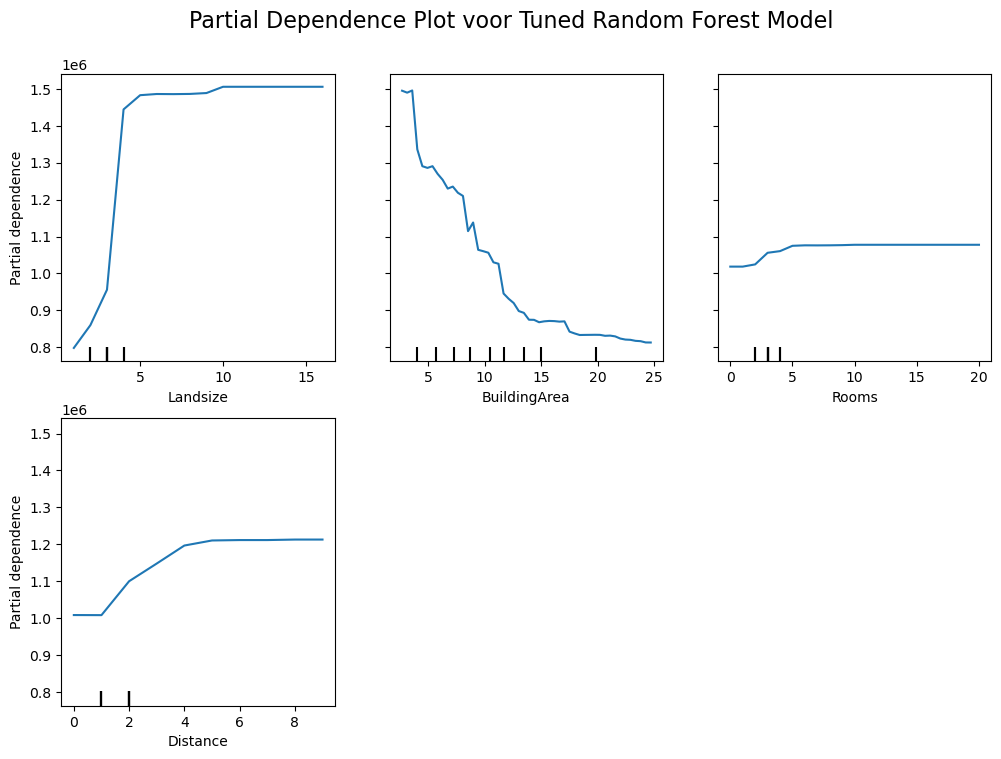

In [153]:
selected_features_for_pdp = ['Landsize', 'BuildingArea', 'Rooms', 'Distance']

fig, ax = plt.subplots(figsize=(12, 8))
disp = PartialDependenceDisplay.from_estimator(
    best_rf_model,
    X_rf_train_no_impute,
    features=[0, 1, 2, 3],
    feature_names=selected_features_for_pdp,
    grid_resolution=50,
    ax=ax
)

plt.suptitle("Partial Dependence Plot voor Tuned Random Forest Model", fontsize=16)
plt.subplots_adjust(top=0.9)
plt.show()

Bovenstaande grafieken vertellen het volgende:

- Hoe groter de oppervlakte van het gehele land, hoe meer de prijs stijgt. De prijs stijgt al heel snel naarmate het land groter wordt, en stijgt daarna wat minder wanneer een bepaald oppervlakte is bereikt. Dit insinueerd dat de woning prijs op een gegeven moment niet meer grotendeels afhankelijk is van de landgrootte, maar dat er naar andere kolommen wordt gekeken.

- Hoe groter de oppervlakte van de woning, hoe minder de prijs. Dit lijkt een fout te zijn want in de werkelijkheid is het duidelijk omgekeerd. Een enige verklaring kan de aanwezigheid van uitschieters zijn, als er veel uitschieters zijn die een ontzettend grote waarde hebben in vergelijking met de andere waardes, dan zal de invloed van deze kleine waardes al snel veel lager liggen dan de andere waardes doordat deze ook geschaald zijn.

- Het aantal kamers zorgt ook voor een stijging in prijs, al is er net zoals met de landgrootte te zien dat deze na een bepaalde waarde niet meer stijgt. Ook hier kan het geval zijn dat de prijs dan meer af gaat hangen van andere waardes.

- De afstand tot het centrum heeft ook een stijging in prijs naarmate deze afstand groter wordt. Dit is mogelijk te verklaren door te bedenken dat het centrum meestal bestaat uit appartementen en de omringende gebieden wat grotere en duurdere huizen kan hebben.

<b>XAI Technieken</b>

Techniek: LIME

In [249]:
selected_features_for_lime = ['BuildingArea', 'Landsize']
X_lime = X_rf_train_no_impute[selected_features_for_lime].values
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_rf_train_no_impute.values,  
    feature_names=X_rf_train_no_impute.columns.tolist(),  
    mode='regression',  
    discretize_continuous=False  
)

instance_index = 10
instance = pd.DataFrame([X_rf_train_no_impute.iloc[instance_index]], columns=X_rf_train_no_impute.columns)

exp = explainer.explain_instance(instance.iloc[0].values, best_rf_model.predict)
exp.show_in_notebook()

C:\Users\luukk\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Dit model laat het volgende zien:

- Voorspelde waarde ligt tussen <b>296025.64 AUD</b> en <b>4909841.52 AUD</b>
- Distance, Type_u, en Regionname_Western Metropolitan hebben allemaal een negatieve invloed op de woning prijs.
- Ondanks onze eerdere visualisatie lijkt er hier te blijken dat een locatie weg van het centrum juist voor een lagere prijs zorgt.
- Ook is er af te lezen dat woningen binnenin Western Metropolitan prijzen laat dalen.
- Telbare features zoals het aantal kamers zorgen allemaal voor een prijsstijging.
- Ook woningen in bepaalde regio's, gemeentes, en wijken zorgen voor een prijsstijging.
- Tenslotte zorgt de land grootte ook voor een stijging in prijs, maar is de woning grootte hier niet te zien, wat de vorige observatie een beetje versterkt.

Het model kan als volgt worden samengevat:

- Het voorspellen van de prijs is heel erg afhankelijk van de locatie van het huis.
- Of de woning in een bepaald gebied staat, en hoe ver dit van het centrum is zijn features die hierbij een grote rol spelen.
- Ook het aantal telbare waardes zoals kamers en badkamers zijn heel belangrijk in de voorspelling van de prijs.

<div id=section8>
<h2><b>Conclusie</b></h2>

Conclusie: Inzicht in het Random Forest Model voor Melbourne Woningprijzen

Na het toepassen van Verklaarbare AI (XAI) technieken, waaronder PDP, SHAP, en LIME, zijn er waardevolle inzichten verkregen in hoe het Random Forest model woningprijzen in Melbourne voorspelt. Hieronder volgen de belangrijkste bevindingen:

1. Feature Belangrijkheid & Modelgedrag

- De meest invloedrijke features in het model waren Rooms, Landsize, Distance, Regionname en Type.
- Een hoger aantal kamers en een grotere grondoppervlakte resulteerden over het algemeen in hogere prijzen, wat de standaard trends in de vastgoedmarkt bevestigt.
- De afstand tot de stad verminderde de vastgoedwaarde significant, wat wijst op een sterke voorkeur voor stedelijke locaties.
Regio en Gemeenteraadsgebied speelden een belangrijke rol, waarbij woningen in Southern Metropolitan en Stonnington City Council hoger geprijsd waren.

2. Onverwachte Bevindingen

- BuildingArea had een negatieve impact in de PDP: Dit suggereert data-inconsistenties of interacties die de interpretatie van deze feature beïnvloeden.
- Ook was het nieuwe model dat was gebaseerd op belangrijke parameter combinaties en features niet meer geschikt voor de imputatie dan andere modellen.

3. XAI Methoden: Sterktes & Beperkingen

- PDP gaf een algemeen begrip van hoe elke belangrijke feature uit de RF-selectie de prijs beïnvloedt, maar was misleidend voor BuildingArea vanwege mogelijke datasetproblemen.
- SHAP leverde gedetailleerde feature-impact, maar was rekenintensief, en was daardoor uiteindelijk niet gebruikt.
- LIME was effectief in het verklaren van individuele voorspellingen, en gaf inzichten over belangrijke features die niet eerder waren bevonden.

4. Volgende Stappen & Verbeteringen

- Onderzoek de interacties tussen BuildingArea en andere features om te begrijpen waarom het effect negatief lijkt.
-Voer verdere feature engineering uit, mogelijk door features te combineren of te transformeren. Hier zal dan vooral worden gekeken naar geografische waardes gezien deze een hoge invloed hadden op de prijs.
- Test alternatieve modellen, zoals XGBoost of Gradient Boosting, om de prestaties en interpreteerbaarheid te vergelijken.
- Verfijn de hyperparameter tuning om de modelnauwkeurigheid en generaliseerbaarheid te verbeteren.

<b>Reflectie</b>

De toepassing van deze opdracht was erg lastig omdat het doel van deze dataset Lineaire Regressie was, maar de uiteindelijke modellen daar totaal niet goed mee werkte, en het uit verder onderzoek duidelijk werd dat de andere soort features juist meer invloed hadden op de prijs.

Daarnaast was de dataset niet perfect schoongemaakt, en kwamen er daardoor inconsistencies naar voren in verschillende model-evaluaties en XAI-toepassingen.

Tenslotte zijn er een aantal berekeningen die gewoonweg te lang duren om toe te passen in dit Notebook, waardoor de analyse mogelijk slechter of niet diep genoeg is dan origineel was bedoeld.

Voor een volgende keer zal er een overweging worden gemaakt om rijen met extreme uitschieters te verwijderen, omdat deze mogelijk voor te veel verstoring hebben gezorgd in de model-evaluatie en de XAI-toepassing.

Daarnaast zal er gekeken worden of er bepaalde optimalisaties kunnen worden toegepast om het model nog precieser te maken, zodat deze ook toepasbaar is op eigen tests.

Ook valt er te zeggen dat dit rapport niet ontzettend slecht is, in dat alle basis-elementen van ML-learning naar voren komen, en het ervoor heeft gezorgd dat waardevolle inzichten zijn verkregen in de vorm van data-interpretatie, model-toepassingen, en XAI-toepassingen. Ondanks het feit dat het model niet persé bruikbaar is, heeft het toch een behaald resultaat geworven in de vorm van kenmerken van Machine-Learning aan te leren.